初步尝试构建多模态模型：

In [17]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# 配置类
class Config:
    base_path = r"D:\大学作业\当代人工智能\实验五\project5"
    data_path = os.path.join(base_path, "data")
    train_file = os.path.join(base_path, "train.txt")
    test_file = os.path.join(base_path, "test_without_label.txt")
    
    text_model = 'bert-base-uncased'
    image_model = 'resnet50'
    
    batch_size = 16
    num_epochs = 10
    learning_rate = 2e-5
    weight_decay = 1e-4
    
    text_dim = 768
    image_dim = 2048
    hidden_dim = 256
    num_classes = 3
    dropout = 0.3
    
    image_size = 224
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    num_workers = 0

config = Config()
print(f"使用设备: {config.device}")

# 数据集类
class MultimodalDataset(Dataset):
    def __init__(self, data_list, transform=None, mode='train'):
        self.data_list = data_list
        self.transform = transform
        self.mode = mode
        self.tokenizer = BertTokenizer.from_pretrained(config.text_model)
        self.label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
        self.reverse_label_map = {v: k for k, v in self.label_map.items()}
        print(f"数据集初始化完成，共有 {len(data_list)} 条数据")
    
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        try:
            guid, text, label = self.data_list[idx]
            
            if not text or len(text.strip()) == 0:
                text = "no text available"
            
            text_encoding = self.tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=64,
                return_tensors='pt'
            )
            
            img_path = os.path.join(config.data_path, f"{guid}.jpg")
            try:
                image = Image.open(img_path).convert('RGB')
            except:
                image = Image.new('RGB', (config.image_size, config.image_size), color='gray')
            
            if self.transform:
                image = self.transform(image)
            
            if self.mode != 'test':
                label_idx = self.label_map[label]
                return {
                    'input_ids': text_encoding['input_ids'].squeeze(0),
                    'attention_mask': text_encoding['attention_mask'].squeeze(0),
                    'image': image,
                    'label': torch.tensor(label_idx, dtype=torch.long),
                    'guid': guid
                }
            else:
                return {
                    'input_ids': text_encoding['input_ids'].squeeze(0),
                    'attention_mask': text_encoding['attention_mask'].squeeze(0),
                    'image': image,
                    'guid': guid
                }
        except Exception as e:
            print(f"处理数据 {idx} 时出错: {e}")
            return self.__getitem__((idx + 1) % len(self.data_list))

# 加载数据
def load_data():
    train_data = []
    with open(config.train_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in tqdm(lines[1:], desc="加载训练数据"):
            line = line.strip()
            if line:
                parts = line.split(',')
                if len(parts) >= 2:
                    guid, label = parts[0], parts[1]
                    txt_path = os.path.join(config.data_path, f"{guid}.txt")
                    try:
                        with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                            text = txt_f.read().strip()
                    except:
                        text = ""
                    train_data.append((guid, text, label))
    
    test_data = []
    with open(config.test_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in tqdm(lines[1:], desc="加载测试数据"):
            line = line.strip()
            if line:
                parts = line.split(',')
                if len(parts) >= 2:
                    guid, label = parts[0], parts[1]
                else:
                    guid = parts[0]
                    label = None
                txt_path = os.path.join(config.data_path, f"{guid}.txt")
                try:
                    with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                        text = txt_f.read().strip()
                except:
                    text = ""
                test_data.append((guid, text, label))
    
    print(f"加载了 {len(train_data)} 条训练数据, {len(test_data)} 条测试数据")
    return train_data, test_data

# 多模态融合模型
class MultimodalModel(nn.Module):
    def __init__(self):
        super(MultimodalModel, self).__init__()
        
        self.text_encoder = BertModel.from_pretrained(config.text_model)
        for param in self.text_encoder.parameters():
            param.requires_grad = False
        for param in self.text_encoder.encoder.layer[-2:].parameters():
            param.requires_grad = True
        
        self.image_encoder = models.resnet50(pretrained=True)
        self.image_encoder = nn.Sequential(*list(self.image_encoder.children())[:-2])
        self.image_pool = nn.AdaptiveAvgPool2d((1, 1))
        for param in self.image_encoder.parameters():
            param.requires_grad = False
        for param in list(self.image_encoder.children())[-4:]:
            for p in param.parameters():
                p.requires_grad = True
        
        self.text_fc = nn.Linear(config.text_dim, config.hidden_dim)
        self.image_fc = nn.Linear(2048, config.hidden_dim)
        self.fusion = nn.Sequential(
            nn.Linear(config.hidden_dim * 2, config.hidden_dim),
            nn.ReLU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim, config.num_classes)
        )
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, input_ids, attention_mask, image):
        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_features = text_out.last_hidden_state[:, 0, :]
        text_features = self.relu(self.text_fc(text_features))
        text_features = self.dropout(text_features)
        
        image_features = self.image_encoder(image)
        image_features = self.image_pool(image_features)
        image_features = image_features.view(image_features.size(0), -1)
        image_features = self.relu(self.image_fc(image_features))
        image_features = self.dropout(image_features)
        
        fused = torch.cat([text_features, image_features], dim=1)
        output = self.fusion(fused)
        
        return output

# 训练器类
class Trainer:
    def __init__(self, model, train_loader, val_loader, model_name):
        self.model = model.to(config.device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.model_name = model_name
        
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=config.learning_rate,
            weight_decay=config.weight_decay
        )
        
        self.best_accuracy = 0
        self.history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    def train_epoch(self):
        self.model.train()
        total_loss = 0
        total_batches = len(self.train_loader)
        
        for batch_idx, batch in enumerate(tqdm(self.train_loader, desc="训练中", leave=False)):
            input_ids = batch['input_ids'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            images = batch['image'].to(config.device)
            labels = batch['label'].to(config.device)
            
            self.optimizer.zero_grad()
            outputs = self.model(input_ids, attention_mask, images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            
            total_loss += loss.item()
            
            if (batch_idx + 1) % 100 == 0:
                print(f"  Batch {batch_idx+1}/{total_batches}, Loss: {loss.item():.4f}")
        
        return total_loss / total_batches
    
    def validate(self):
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc="验证中", leave=False):
                input_ids = batch['input_ids'].to(config.device)
                attention_mask = batch['attention_mask'].to(config.device)
                images = batch['image'].to(config.device)
                labels = batch['label'].to(config.device)
                
                outputs = self.model(input_ids, attention_mask, images)
                loss = self.criterion(outputs, labels)
                total_loss += loss.item()
                
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        accuracy = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='weighted')
        return total_loss / len(self.val_loader), accuracy, f1, all_preds, all_labels
    
    def train(self, epochs=None):
        if epochs is None:
            epochs = config.num_epochs
            
        print(f"\n开始训练 {self.model_name}，共 {epochs} 个epoch...")
        
        for epoch in range(epochs):
            start_time = time.time()
            print(f"\nEpoch {epoch+1}/{epochs}:")
            
            train_loss = self.train_epoch()
            val_loss, val_acc, val_f1, _, _ = self.validate()
            
            epoch_time = time.time() - start_time
            
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            
            print(f"  Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            print(f"  Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
            print(f"  耗时: {epoch_time:.1f}秒")
            
            if val_acc > self.best_accuracy:
                self.best_accuracy = val_acc
                torch.save(self.model.state_dict(), f'best_{self.model_name}.pth')
                print(f"  保存最佳模型，准确率: {val_acc:.4f}")
        
        print(f"\n{self.model_name} 训练完成，最佳验证准确率: {self.best_accuracy:.4f}")
    
    def get_results(self):
        self.model.load_state_dict(torch.load(f'best_{self.model_name}.pth'))
        val_loss, val_acc, val_f1, preds, labels = self.validate()
        
        report = classification_report(
            labels, preds, 
            target_names=['positive', 'neutral', 'negative'],
            output_dict=True
        )
        
        return {
            'accuracy': val_acc,
            'weighted_f1': val_f1,
            'history': self.history
        }

# 主函数：多模态模型训练和预测
def run_multimodal_experiment():
    print("=" * 60)
    print("多模态情感分类模型训练和预测")
    print("=" * 60)
    
    # 加载数据
    print("\n1. 加载数据...")
    train_data, test_data = load_data()
    
    # 划分训练集和验证集（使用全部数据）
    print(f"\n2. 划分训练集和验证集...")
    print(f"训练数据总数: {len(train_data)}")
    
    # 直接使用全部训练数据，而不是采样
    train_data_full, val_data = train_test_split(
        train_data, 
        test_size=0.2, 
        random_state=42, 
        stratify=[d[2] for d in train_data]  # 按标签分层抽样
    )
    
    print(f"训练集: {len(train_data_full)}, 验证集: {len(val_data)}, 测试集: {len(test_data)}")
    
    #  数据预处理
    train_transform = transforms.Compose([
        transforms.Resize((config.image_size, config.image_size)),
        transforms.RandomHorizontalFlip(p=0.3),  # 添加数据增强
        transforms.RandomRotation(10),  # 添加数据增强
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((config.image_size, config.image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 创建数据集和数据加载器
    print("\n3. 创建数据集...")
    train_dataset = MultimodalDataset(train_data_full, transform=train_transform)
    val_dataset = MultimodalDataset(val_data, transform=val_transform)
    test_dataset = MultimodalDataset(test_data, transform=val_transform, mode='test')
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=config.num_workers
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers
    )
    
    # 训练多模态模型
    print("\n" + "=" * 60)
    print("训练多模态模型")
    print("=" * 60)
    
    model = MultimodalModel()
    print(f"模型参数总数: {sum(p.numel() for p in model.parameters())}")
    print(f"可训练参数数: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
    
    trainer = Trainer(model, train_loader, val_loader, "multimodal")
    trainer.train(epochs=config.num_epochs)
    results = trainer.get_results()
    
    # 保存结果
    results_df = pd.DataFrame([['多模态模型', results['accuracy'], results['weighted_f1']]], 
                             columns=['模型', '准确率', '加权F1'])
    results_df.to_csv('multimodal_results.csv', index=False, float_format='%.4f')
    
    # 在测试集上进行预测
    print("\n" + "=" * 60)
    print("在测试集上进行预测")
    print("=" * 60)
    
    # 加载最佳模型
    model.load_state_dict(torch.load('best_multimodal.pth'))
    model = model.to(config.device)
    model.eval()
    
    predictions = []
    guids = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="测试集预测"):
            input_ids = batch['input_ids'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            images = batch['image'].to(config.device)
            batch_guids = batch['guid']
            
            outputs = model(input_ids, attention_mask, images)
            _, preds = torch.max(outputs, 1)
            
            predictions.extend(preds.cpu().numpy())
            guids.extend(batch_guids)
    
    # 映射回标签
    label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
    reverse_map = {v: k for k, v in label_map.items()}
    predictions_labels = [reverse_map[pred] for pred in predictions]
    
    # 保存预测结果映射
    pred_dict = dict(zip(guids, predictions_labels))
    
    # 更新原始文件
    with open(config.test_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    new_lines = [lines[0]]  # 标题行
    for line in lines[1:]:
        line = line.strip()
        if line:
            parts = line.split(',')
            guid = parts[0]
            pred_label = pred_dict.get(guid, 'neutral')
            new_lines.append(f'{guid},{pred_label}\n')
    
    # 直接覆盖原测试文件
    output_file = config.test_file  
    with open(output_file, 'w', encoding='utf-8') as f:
        f.writelines(new_lines)
    
    print(f"\n多模态模型预测结果已保存到: {output_file}")
    print(f"  共预测了 {len(predictions)} 条测试数据")
    print(f"  验证准确率: {results['accuracy']:.4f}")
    print(f"  加权F1分数: {results['weighted_f1']:.4f}")
    
    # 显示预测结果分布
    print("\n预测结果分布:")
    for label_name in ['positive', 'neutral', 'negative']:
        count = list(predictions_labels).count(label_name)
        print(f"  {label_name}: {count} ({count/len(predictions_labels)*100:.1f}%)")
    
    return results, pred_dict

# 运行多模态实验
if __name__ == "__main__":
    try:
        multimodal_results, multimodal_predictions = run_multimodal_experiment()

    except Exception as e:
        print(f"运行过程中出现错误: {e}")
        import traceback
        traceback.print_exc()

使用设备: cpu
多模态情感分类模型训练和预测

1. 加载数据...


加载测试数据: 100%|████████████████████████████████████████████████████████████████| 511/511 [00:00<00:00, 7405.62it/s]


加载了 4000 条训练数据, 511 条测试数据

2. 划分训练集和验证集...
训练数据总数: 4000
训练集: 3200, 验证集: 800, 测试集: 511

3. 创建数据集...
数据集初始化完成，共有 3200 条数据
数据集初始化完成，共有 800 条数据
数据集初始化完成，共有 511 条数据

训练多模态模型
模型参数总数: 133843779
可训练参数数: 38527747

开始训练 multimodal，共 10 个epoch...

Epoch 1/10:


训练中:  50%|████████████████████████████████████                                    | 100/200 [05:45<05:51,  3.52s/it]

  Batch 100/200, Loss: 0.6783


...

  Batch 200/200, Loss: 0.0183


  Train Loss: 0.1176, Val Loss: 1.5773
  Val Acc: 0.6963, Val F1: 0.6766
  耗时: 803.0秒

multimodal 训练完成，最佳验证准确率: 0.7212



在测试集上进行预测


测试集预测: 100%|██████████████████████████████████████████████████████████████████████| 32/32 [00:49<00:00,  1.56s/it]


多模态模型预测结果已保存到: D:\大学作业\当代人工智能\实验五\project5\test_without_label.txt
  共预测了 511 条测试数据
  验证准确率: 0.7212
  加权F1分数: 0.6891

预测结果分布:
  positive: 378 (74.0%)
  neutral: 5 (1.0%)
  negative: 128 (25.0%)


进行消融实验：

消融实验


加载测试数据: 100%|████████████████████████████████████████████████████████████████| 511/511 [00:00<00:00, 9283.61it/s]


加载了 4000 条训练数据, 511 条测试数据

进行消融实验:
训练数据总数: 4000
验证集大小: 800
测试集大小: 511
数据集初始化完成，共有 800 条数据

加载训练好的多模态模型...
找到模型文件: best_multimodal.pth
模型加载成功！

测试：仅文本输入



仅文本输入详细分类报告:
----------------------------------------
              precision    recall  f1-score   support

    positive       0.80      0.67      0.72       478
     neutral       0.44      0.25      0.32        84
    negative       0.53      0.78      0.63       238

    accuracy                           0.66       800
   macro avg       0.59      0.56      0.56       800
weighted avg       0.68      0.66      0.65       800

仅文本输入 - 准确率: 0.6550, 加权F1: 0.6528

测试：仅图像输入



仅图像输入详细分类报告:
----------------------------------------
              precision    recall  f1-score   support

    positive       0.61      1.00      0.76       478
     neutral       0.00      0.00      0.00        84
    negative       0.86      0.08      0.15       238

    accuracy                           0.62       800
   macro avg       0.49      0.36      0.30       800
weighted avg       0.62      0.62      0.50       800

仅图像输入 - 准确率: 0.6200, 加权F1: 0.4977

测试：多模态输入



多模态输入详细分类报告:
----------------------------------------
              precision    recall  f1-score   support

    positive       0.74      0.90      0.81       478
     neutral       0.75      0.11      0.19        84
    negative       0.67      0.58      0.62       238

    accuracy                           0.72       800
   macro avg       0.72      0.53      0.54       800
weighted avg       0.72      0.72      0.69       800

多模态输入 - 准确率: 0.7212, 加权F1: 0.6891

消融实验结果汇总

同一多模态模型在不同输入方式下的表现:
------------------------------------------------------------
   输入方式     准确率     加权F1
  仅文本输入 0.65500 0.652790
  仅图像输入 0.62000 0.497676
完整多模态输入 0.72125 0.689128


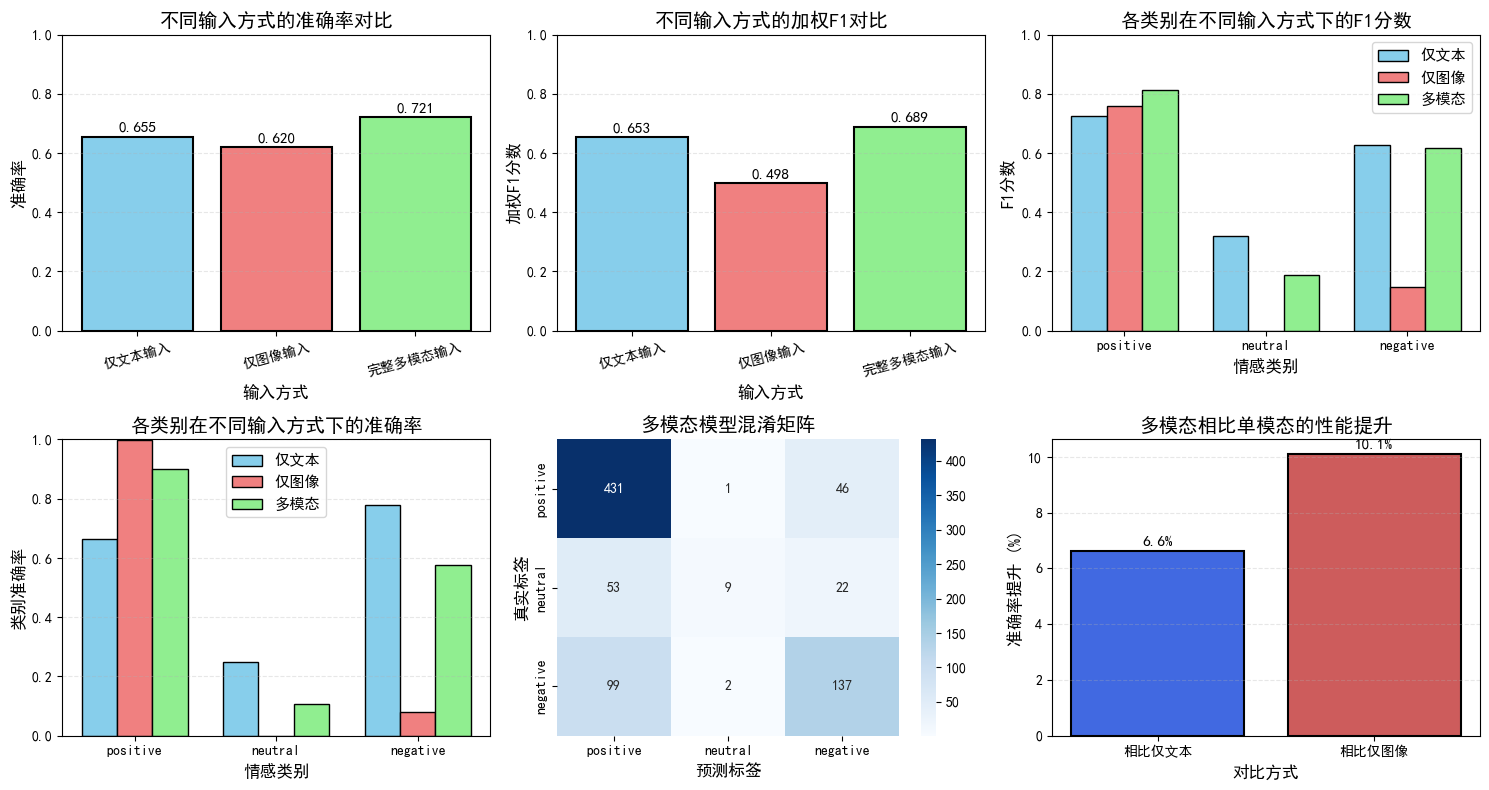


消融实验总结

实验设置:
- 验证集大小: 800 条数据
- 使用模型: 训练好的多模态模型
- 评估方式: 同一模型在不同输入条件下的表现

实验结果:
1. 仅文本输入准确率: 0.6550 (加权F1: 0.6528)
2. 仅图像输入准确率: 0.6200 (加权F1: 0.4977)
3. 完整多模态输入准确率: 0.7212 (加权F1: 0.6891)

性能提升分析:
多模态相比仅文本提升: 6.62% (绝对), 10.11% (相对)
多模态相比仅图像提升: 10.12% (绝对), 16.33% (相对)


In [18]:
print("=" * 60)
print("消融实验")
print("=" * 60)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from transformers import BertTokenizer, BertModel
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

# 使用全局的config配置

# 重新加载数据
train_data, test_data = load_data()

# 使用与主实验相同的划分方式
train_data_full, val_data = train_test_split(
    train_data, 
    test_size=0.2, 
    random_state=42, 
    stratify=[d[2] for d in train_data]
)

print(f"\n进行消融实验:")
print(f"训练数据总数: {len(train_data)}")
print(f"验证集大小: {len(val_data)}")
print(f"测试集大小: {len(test_data)}")

# 数据预处理
val_transform = transforms.Compose([
    transforms.Resize((config.image_size, config.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 创建验证集
val_dataset = MultimodalDataset(val_data, transform=val_transform)
val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers
)

# 重新定义 MultimodalModel 类，确保正确引用 models
class MultimodalModel(nn.Module):
    def __init__(self):
        super(MultimodalModel, self).__init__()
        
        self.text_encoder = BertModel.from_pretrained(config.text_model)
        for param in self.text_encoder.parameters():
            param.requires_grad = False
        for param in self.text_encoder.encoder.layer[-2:].parameters():
            param.requires_grad = True
        
        # 明确使用 torchvision.models
        self.image_encoder = models.resnet50(pretrained=True)
        self.image_encoder = nn.Sequential(*list(self.image_encoder.children())[:-2])
        self.image_pool = nn.AdaptiveAvgPool2d((1, 1))
        for param in self.image_encoder.parameters():
            param.requires_grad = False
        for param in list(self.image_encoder.children())[-4:]:
            for p in param.parameters():
                p.requires_grad = True
        
        self.text_fc = nn.Linear(config.text_dim, config.hidden_dim)
        self.image_fc = nn.Linear(2048, config.hidden_dim)
        self.fusion = nn.Sequential(
            nn.Linear(config.hidden_dim * 2, config.hidden_dim),
            nn.ReLU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim, config.num_classes)
        )
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, input_ids, attention_mask, image):
        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_features = text_out.last_hidden_state[:, 0, :]
        text_features = self.relu(self.text_fc(text_features))
        text_features = self.dropout(text_features)
        
        image_features = self.image_encoder(image)
        image_features = self.image_pool(image_features)
        image_features = image_features.view(image_features.size(0), -1)
        image_features = self.relu(self.image_fc(image_features))
        image_features = self.dropout(image_features)
        
        fused = torch.cat([text_features, image_features], dim=1)
        output = self.fusion(fused)
        
        return output

# 加载训练好的多模态模型
print("\n加载训练好的多模态模型...")
try:
    model = MultimodalModel()
    # 检查模型文件是否存在
    model_path = 'best_multimodal.pth'
    if os.path.exists(model_path):
        print(f"找到模型文件: {model_path}")
        model.load_state_dict(torch.load(model_path, map_location=config.device))
        model = model.to(config.device)
        model.eval()
        print("模型加载成功！")
    else:
        print(f"模型文件不存在: {model_path}")
        print("请先运行主实验进行训练")
        exit()
except Exception as e:
    print(f"模型加载失败: {e}")
    import traceback
    traceback.print_exc()
    exit()

# 1. 测试仅文本输入
print("\n" + "=" * 30)
print("测试：仅文本输入")
print("=" * 30)

def evaluate_text_only():
    """仅使用文本数据进行评估"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="仅文本评估", leave=False):
            input_ids = batch['input_ids'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            labels = batch['label'].to(config.device)
            
            # 获取文本特征
            text_out = model.text_encoder(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            text_features = text_out.last_hidden_state[:, 0, :]
            text_features = model.relu(model.text_fc(text_features))
            text_features = model.dropout(text_features)
            
            # 创建零图像特征
            batch_size = input_ids.size(0)
            zero_image_features = torch.zeros(batch_size, model.image_fc.out_features).to(config.device)
            
            # 融合特征（文本 + 零图像）
            fused = torch.cat([text_features, zero_image_features], dim=1)
            output = model.fusion(fused)
            
            _, preds = torch.max(output, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # 强制转换为Python原生float
    accuracy = float(accuracy_score(all_labels, all_preds))
    f1 = float(f1_score(all_labels, all_preds, average='weighted'))
    
    # 详细分类报告
    print("\n仅文本输入详细分类报告:")
    print("-" * 40)
    report = classification_report(all_labels, all_preds, 
                                   target_names=['positive', 'neutral', 'negative'])
    print(report)
    
    return accuracy, f1, all_preds, all_labels

text_only_acc, text_only_f1, text_preds, text_labels = evaluate_text_only()
print(f"仅文本输入 - 准确率: {text_only_acc:.4f}, 加权F1: {text_only_f1:.4f}")

# 2. 测试仅图像输入
print("\n" + "=" * 30)
print("测试：仅图像输入")
print("=" * 30)

def evaluate_image_only():
    """仅使用图像数据进行评估"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="仅图像评估", leave=False):
            images = batch['image'].to(config.device)
            labels = batch['label'].to(config.device)
            
            # 获取图像特征
            image_features = model.image_encoder(images)
            image_features = model.image_pool(image_features)
            image_features = image_features.view(image_features.size(0), -1)
            image_features = model.relu(model.image_fc(image_features))
            image_features = model.dropout(image_features)
            
            # 创建零文本特征
            batch_size = images.size(0)
            zero_text_features = torch.zeros(batch_size, model.text_fc.out_features).to(config.device)
            
            # 融合特征（零文本 + 图像）
            fused = torch.cat([zero_text_features, image_features], dim=1)
            output = model.fusion(fused)
            
            _, preds = torch.max(output, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # 强制转换为Python原生float
    accuracy = float(accuracy_score(all_labels, all_preds))
    f1 = float(f1_score(all_labels, all_preds, average='weighted'))
    
    # 详细分类报告
    print("\n仅图像输入详细分类报告:")
    print("-" * 40)
    report = classification_report(all_labels, all_preds, 
                                   target_names=['positive', 'neutral', 'negative'])
    print(report)
    
    return accuracy, f1, all_preds, all_labels

image_only_acc, image_only_f1, image_preds, image_labels = evaluate_image_only()
print(f"仅图像输入 - 准确率: {image_only_acc:.4f}, 加权F1: {image_only_f1:.4f}")

# 3. 完整多模态测试（用于对比）
print("\n" + "=" * 30)
print("测试：多模态输入")
print("=" * 30)

def evaluate_full_multimodal():
    """使用多模态数据进行评估"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="完整多模态评估", leave=False):
            input_ids = batch['input_ids'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            images = batch['image'].to(config.device)
            labels = batch['label'].to(config.device)
            
            outputs = model(input_ids, attention_mask, images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # 关键修改3：强制转换为Python原生float
    accuracy = float(accuracy_score(all_labels, all_preds))
    f1 = float(f1_score(all_labels, all_preds, average='weighted'))
    
    # 详细分类报告
    print("\n多模态输入详细分类报告:")
    print("-" * 40)
    report = classification_report(all_labels, all_preds, 
                                   target_names=['positive', 'neutral', 'negative'])
    print(report)
    
    return accuracy, f1, all_preds, all_labels

full_acc, full_f1, full_preds, full_labels = evaluate_full_multimodal()
print(f"多模态输入 - 准确率: {full_acc:.4f}, 加权F1: {full_f1:.4f}")

# 4. 结果汇总和对比
print("\n" + "=" * 60)
print("消融实验结果汇总")
print("=" * 60)

# 直接使用已经确保是Python原生float的值
results_data = [
    ['仅文本输入', text_only_acc, text_only_f1],
    ['仅图像输入', image_only_acc, image_only_f1],
    ['完整多模态输入', full_acc, full_f1]
]

results_df = pd.DataFrame(results_data, columns=['输入方式', '准确率', '加权F1'])
print("\n同一多模态模型在不同输入方式下的表现:")
print("-" * 60)
print(results_df.to_string(index=False))

# 5. 绘制性能对比图
plt.figure(figsize=(15, 8))

# 子图1：准确率对比
plt.subplot(2, 3, 1)
models_list = results_df['输入方式']
accuracies = results_df['准确率'].values

colors = ['skyblue', 'lightcoral', 'lightgreen']
bars = plt.bar(models_list, accuracies, color=colors, edgecolor='black', linewidth=1.5)
plt.xlabel('输入方式', fontsize=12)
plt.ylabel('准确率', fontsize=12)
plt.title('不同输入方式的准确率对比', fontsize=14, fontweight='bold')
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.xticks(rotation=15)

# 在柱子上显示数值
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 子图2：加权F1对比
plt.subplot(2, 3, 2)
f1_scores = results_df['加权F1'].values
bars = plt.bar(models_list, f1_scores, color=colors, edgecolor='black', linewidth=1.5)
plt.xlabel('输入方式', fontsize=12)
plt.ylabel('加权F1分数', fontsize=12)
plt.title('不同输入方式的加权F1对比', fontsize=14, fontweight='bold')
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.xticks(rotation=15)

for bar, f1 in zip(bars, f1_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{f1:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 子图3：各类别F1分数对比
plt.subplot(2, 3, 3)

# 获取详细分类报告
def get_classification_details(preds, labels):
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average=None)
    return precision.astype(float), recall.astype(float), f1.astype(float)

text_precision, text_recall, text_f1 = get_classification_details(text_preds, text_labels)
image_precision, image_recall, image_f1 = get_classification_details(image_preds, image_labels)
full_precision, full_recall, full_f1_class = get_classification_details(full_preds, full_labels)

x = np.arange(3)  # 3个类别
width = 0.25

bars1 = plt.bar(x - width, text_f1, width, label='仅文本', color='skyblue', edgecolor='black')
bars2 = plt.bar(x, image_f1, width, label='仅图像', color='lightcoral', edgecolor='black')
bars3 = plt.bar(x + width, full_f1_class, width, label='多模态', color='lightgreen', edgecolor='black')

plt.xlabel('情感类别', fontsize=12)
plt.ylabel('F1分数', fontsize=12)
plt.title('各类别在不同输入方式下的F1分数', fontsize=14, fontweight='bold')
plt.xticks(x, ['positive', 'neutral', 'negative'])
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.ylim(0, 1.0)

# 子图4：各类别准确率对比
plt.subplot(2, 3, 4)
categories = ['positive', 'neutral', 'negative']

# 计算每个类别的准确率
def get_class_accuracy(preds, labels):
    cm = confusion_matrix(labels, preds)
    class_acc = cm.diagonal() / cm.sum(axis=1)
    return class_acc.astype(float)

text_class_acc = get_class_accuracy(text_preds, text_labels)
image_class_acc = get_class_accuracy(image_preds, image_labels)
full_class_acc = get_class_accuracy(full_preds, full_labels)

bars1 = plt.bar(x - width, text_class_acc, width, label='仅文本', color='skyblue', edgecolor='black')
bars2 = plt.bar(x, image_class_acc, width, label='仅图像', color='lightcoral', edgecolor='black')
bars3 = plt.bar(x + width, full_class_acc, width, label='多模态', color='lightgreen', edgecolor='black')

plt.xlabel('情感类别', fontsize=12)
plt.ylabel('类别准确率', fontsize=12)
plt.title('各类别在不同输入方式下的准确率', fontsize=14, fontweight='bold')
plt.xticks(x, categories)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.ylim(0, 1.0)

# 子图5：混淆矩阵热力图
plt.subplot(2, 3, 5)
# 使用多模态的混淆矩阵
cm = confusion_matrix(full_labels, full_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['positive', 'neutral', 'negative'],
            yticklabels=['positive', 'neutral', 'negative'])
plt.xlabel('预测标签', fontsize=12)
plt.ylabel('真实标签', fontsize=12)
plt.title('多模态模型混淆矩阵', fontsize=14, fontweight='bold')

# 子图6：性能提升百分比
plt.subplot(2, 3, 6)
# 计算性能提升
text_improvement = (full_acc - text_only_acc) * 100
image_improvement = (full_acc - image_only_acc) * 100

improvements = [text_improvement, image_improvement]
labels_imp = ['相比仅文本', '相比仅图像']
colors_imp = ['royalblue', 'indianred']

bars = plt.bar(labels_imp, improvements, color=colors_imp, edgecolor='black', linewidth=1.5)
plt.xlabel('对比方式', fontsize=12)
plt.ylabel('准确率提升 (%)', fontsize=12)
plt.title('多模态相比单模态的性能提升', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y', linestyle='--')

# 添加数值标签
for bar, imp in zip(bars, improvements):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{imp:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 6. 实验总结
print("\n" + "="*60)
print("消融实验总结")
print("="*60)

print(f"\n实验设置:")
print(f"- 验证集大小: {len(val_data)} 条数据")
print(f"- 使用模型: 训练好的多模态模型")
print(f"- 评估方式: 同一模型在不同输入条件下的表现")

print(f"\n实验结果:")
print(f"1. 仅文本输入准确率: {text_only_acc:.4f} (加权F1: {text_only_f1:.4f})")
print(f"2. 仅图像输入准确率: {image_only_acc:.4f} (加权F1: {image_only_f1:.4f})") 
print(f"3. 完整多模态输入准确率: {full_acc:.4f} (加权F1: {full_f1:.4f})")

# 计算性能提升
text_improvement = (full_acc - text_only_acc) * 100
image_improvement = (full_acc - image_only_acc) * 100

# 计算相对提升
text_rel_improvement = (full_acc / text_only_acc - 1) * 100 if text_only_acc > 0 else 0
image_rel_improvement = (full_acc / image_only_acc - 1) * 100 if image_only_acc > 0 else 0

print(f"\n性能提升分析:")
print(f"多模态相比仅文本提升: {text_improvement:.2f}% (绝对), {text_rel_improvement:.2f}% (相对)")
print(f"多模态相比仅图像提升: {image_improvement:.2f}% (绝对), {image_rel_improvement:.2f}% (相对)")

尝试优化模型，比较Late Fusion、Early Fusion和Attention-based Fusion三种策略：

In [19]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from transformers import BertTokenizer, BertModel, AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# 配置类
class Config:
    base_path = r"D:\大学作业\当代人工智能\实验五\project5"
    data_path = os.path.join(base_path, "data")
    train_file = os.path.join(base_path, "train.txt")
    test_file = os.path.join(base_path, "test_without_label.txt")
    
    text_model = 'bert-base-uncased'
    image_model = 'resnet50'
    
    # 完全还原原始参数
    batch_size = 16
    num_epochs = 10
    learning_rate = 2e-5
    weight_decay = 1e-4
    
    text_dim = 768
    image_dim = 2048
    hidden_dim = 256
    num_classes = 3
    dropout = 0.3
    
    image_size = 224
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    num_workers = 0

config = Config()
print(f"使用设备: {config.device}")
print(f"批次大小: {config.batch_size}")

# 数据集类
class MultimodalDataset(Dataset):
    def __init__(self, data_list, transform=None, mode='train', fusion_method='late'):
        self.data_list = data_list
        self.transform = transform
        self.mode = mode
        self.fusion_method = fusion_method
        self.tokenizer = BertTokenizer.from_pretrained(config.text_model)
        self.label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
        self.reverse_label_map = {v: k for k, v in self.label_map.items()}
        print(f"数据集初始化完成，共有 {len(data_list)} 条数据")
    
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        try:
            guid, text, label = self.data_list[idx]
            
            if not text or len(text.strip()) == 0:
                text = "no text available"
            
            text_encoding = self.tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=64,
                return_tensors='pt'
            )
            
            img_path = os.path.join(config.data_path, f"{guid}.jpg")
            try:
                image = Image.open(img_path).convert('RGB')
            except:
                image = Image.new('RGB', (config.image_size, config.image_size), color='gray')
            
            if self.transform:
                image = self.transform(image)
            
            if self.mode != 'test':
                label_idx = self.label_map[label]
                return {
                    'input_ids': text_encoding['input_ids'].squeeze(0),
                    'attention_mask': text_encoding['attention_mask'].squeeze(0),
                    'image': image,
                    'label': torch.tensor(label_idx, dtype=torch.long),
                    'guid': guid,
                    'text': text[:100]  # 仅用于bad case分析
                }
            else:
                return {
                    'input_ids': text_encoding['input_ids'].squeeze(0),
                    'attention_mask': text_encoding['attention_mask'].squeeze(0),
                    'image': image,
                    'guid': guid,
                    'text': text[:100]
                }
        except Exception as e:
            print(f"处理数据 {idx} 时出错: {e}")
            return self.__getitem__((idx + 1) % len(self.data_list))

# 加载数据
def load_data():
    train_data = []
    with open(config.train_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in tqdm(lines[1:], desc="加载训练数据"):
            line = line.strip()
            if line:
                parts = line.split(',')
                if len(parts) >= 2:
                    guid, label = parts[0], parts[1]
                    txt_path = os.path.join(config.data_path, f"{guid}.txt")
                    try:
                        with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                            text = txt_f.read().strip()
                    except:
                        text = ""
                    train_data.append((guid, text, label))
    
    # 统计标签分布
    labels = [d[2] for d in train_data]
    label_counts = {}
    for label in ['positive', 'neutral', 'negative']:
        count = labels.count(label)
        label_counts[label] = count
        print(f"  {label}: {count} ({count/len(labels)*100:.1f}%)")
    
    test_data = []
    # 核心：保存原始test文件中的guid顺序
    original_test_guids = []  
    with open(config.test_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in tqdm(lines[1:], desc="加载测试数据"):
            line = line.strip()
            if line:
                parts = line.split(',')
                guid = parts[0]  # 只提取guid，忽略原文件中的标签
                original_test_guids.append(guid)  # 按原文件行顺序保存
                txt_path = os.path.join(config.data_path, f"{guid}.txt")
                try:
                    with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                        text = txt_f.read().strip()
                except:
                    text = ""
                test_data.append((guid, text, None))  # label设为None
    
    print(f"加载了 {len(train_data)} 条训练数据, {len(test_data)} 条测试数据")
    print(f"已保留原始test文件的guid顺序，共 {len(original_test_guids)} 个guid")
    return train_data, test_data, original_test_guids

# 多模态模型
class MultimodalModel(nn.Module):
    def __init__(self, fusion_method='late'):
        super(MultimodalModel, self).__init__()
        self.fusion_method = fusion_method
        
        # Text Encoder 
        self.text_encoder = BertModel.from_pretrained(config.text_model)
        for param in self.text_encoder.parameters():
            param.requires_grad = False
        for param in self.text_encoder.encoder.layer[-2:].parameters():
            param.requires_grad = True
        
        # Image Encoder 
        self.image_encoder = models.resnet50(pretrained=True)
        self.image_encoder = nn.Sequential(*list(self.image_encoder.children())[:-2])
        self.image_pool = nn.AdaptiveAvgPool2d((1, 1))
        for param in self.image_encoder.parameters():
            param.requires_grad = False
        for param in list(self.image_encoder.children())[-4:]:
            for p in param.parameters():
                p.requires_grad = True
        
        # Fusion Layers 
        self.text_fc = nn.Linear(config.text_dim, config.hidden_dim)
        self.image_fc = nn.Linear(config.image_dim, config.hidden_dim)
        
        if fusion_method == 'late':
            self.fusion = nn.Sequential(
                nn.Linear(config.hidden_dim * 2, config.hidden_dim),
                nn.ReLU(),
                nn.Dropout(config.dropout),
                nn.Linear(config.hidden_dim, config.num_classes)
            )
        elif fusion_method == 'early':
            self.fusion = nn.Sequential(
                nn.Linear(config.hidden_dim * 3, config.hidden_dim),
                nn.ReLU(),
                nn.Dropout(config.dropout),
                nn.Linear(config.hidden_dim, config.num_classes)
            )
        elif fusion_method == 'attention':
            self.attention = nn.MultiheadAttention(config.hidden_dim, num_heads=8, batch_first=True)
            self.fusion = nn.Sequential(
                nn.Linear(config.hidden_dim * 2, config.hidden_dim),
                nn.ReLU(),
                nn.Dropout(config.dropout),
                nn.Linear(config.hidden_dim, config.num_classes)
            )
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, input_ids, attention_mask, image):
        # Text features
        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_features = text_out.last_hidden_state[:, 0, :]
        text_features = self.relu(self.text_fc(text_features))
        text_features = self.dropout(text_features)
        
        # Image features
        image_features = self.image_encoder(image)
        image_features = self.image_pool(image_features)
        image_features = image_features.view(image_features.size(0), -1)
        image_features = self.relu(self.image_fc(image_features))
        image_features = self.dropout(image_features)
        
        # Fusion
        if self.fusion_method == 'late':
            fused = torch.cat([text_features, image_features], dim=1)
        elif self.fusion_method == 'early':
            element_wise = text_features * image_features
            fused = torch.cat([text_features, image_features, element_wise], dim=1)
        elif self.fusion_method == 'attention':
            text_att = text_features.unsqueeze(1)
            image_att = image_features.unsqueeze(1)
            text_out, _ = self.attention(text_att, image_att, image_att)
            image_out, _ = self.attention(image_att, text_att, text_att)
            fused = torch.cat([text_out.squeeze(1), image_out.squeeze(1)], dim=1)
        
        output = self.fusion(fused)
        return output

# 训练器类
class Trainer:
    def __init__(self, model, train_loader, val_loader, model_name):
        self.model = model.to(config.device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.model_name = model_name
        
        # 损失函数和优化器
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=config.learning_rate,
            weight_decay=config.weight_decay
        )
        
        self.best_accuracy = 0
        self.history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    
    def train_epoch(self):
        self.model.train()
        total_loss = 0
        total_batches = len(self.train_loader)
        
        for batch_idx, batch in enumerate(tqdm(self.train_loader, desc="训练中", leave=False)):
            input_ids = batch['input_ids'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            images = batch['image'].to(config.device)
            labels = batch['label'].to(config.device)
            
            self.optimizer.zero_grad()
            outputs = self.model(input_ids, attention_mask, images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            
            total_loss += loss.item()
            
            if (batch_idx + 1) % 100 == 0:
                print(f"  Batch {batch_idx+1}/{total_batches}, Loss: {loss.item():.4f}")
        
        return total_loss / total_batches
    
    def validate(self, return_predictions=False):
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_labels = []
        all_guids = []
        all_texts = []
        
        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc="验证中", leave=False):
                input_ids = batch['input_ids'].to(config.device)
                attention_mask = batch['attention_mask'].to(config.device)
                images = batch['image'].to(config.device)
                labels = batch['label'].to(config.device)
                
                outputs = self.model(input_ids, attention_mask, images)
                loss = self.criterion(outputs, labels)
                total_loss += loss.item()
                
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
                if return_predictions:
                    all_guids.extend(batch['guid'])
                    all_texts.extend(batch['text'])
        
        avg_loss = total_loss / len(self.val_loader)
        accuracy = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='weighted')
        
        if return_predictions:
            return avg_loss, accuracy, f1, all_preds, all_labels, all_guids, all_texts
        return avg_loss, accuracy, f1, all_preds, all_labels
    
    def analyze_bad_cases(self):
        print("\n分析错误案例...")
        
        checkpoint = torch.load(f'best_{self.model_name}.pth', map_location=config.device)
        self.model.load_state_dict(checkpoint)
        
        _, _, _, preds, labels, guids, texts = self.validate(return_predictions=True)
        
        bad_cases = []
        label_map = {0: 'positive', 1: 'neutral', 2: 'negative'}
        
        for i in range(len(preds)):
            if preds[i] != labels[i]:
                bad_cases.append({
                    'guid': guids[i],
                    'true_label': label_map[labels[i]],
                    'pred_label': label_map[preds[i]],
                    'text': texts[i][:100]
                })
        
        # 保存bad case
        bad_cases_df = pd.DataFrame(bad_cases)
        bad_cases_df.to_csv(f'bad_cases_{self.model_name}.csv', index=False, encoding='utf-8')
        
        # 统计错误分布
        print(f"\n错误案例总数: {len(bad_cases)} ({len(bad_cases)/len(preds)*100:.1f}%)")
        print("\n错误类型分布:")
        error_types = []
        for case in bad_cases:
            error_types.append(f"{case['true_label']} -> {case['pred_label']}")
        
        for error_type in sorted(set(error_types)):
            count = error_types.count(error_type)
            print(f"  {error_type}: {count} ({count/len(bad_cases)*100:.1f}%)")
        
        # 绘制混淆矩阵
        cm = confusion_matrix(labels, preds)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['positive', 'neutral', 'negative'],
                    yticklabels=['positive', 'neutral', 'negative'])
        plt.xlabel('预测标签')
        plt.ylabel('真实标签')
        plt.title(f'{self.model_name} 混淆矩阵')
        plt.savefig(f'confusion_matrix_{self.model_name}.png')
        plt.close()
        
        return bad_cases_df
    
    def train(self, epochs=None):
        if epochs is None:
            epochs = config.num_epochs
            
        print(f"\n开始训练 {self.model_name}，共 {epochs} 个epoch...")
        
        for epoch in range(epochs):
            start_time = time.time()
            print(f"\nEpoch {epoch+1}/{epochs}:")
            
            train_loss = self.train_epoch()
            val_loss, val_acc, val_f1, _, _ = self.validate()
            
            epoch_time = time.time() - start_time
            
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.history['val_f1'].append(val_f1)
            
            print(f"  Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            print(f"  Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
            print(f"  耗时: {epoch_time:.1f}秒")
            
            if val_acc > self.best_accuracy:
                self.best_accuracy = val_acc
                torch.save(self.model.state_dict(), f'best_{self.model_name}.pth')
                print(f"  保存最佳模型，准确率: {val_acc:.4f}")
        
        print(f"\n{self.model_name} 训练完成，最佳验证准确率: {self.best_accuracy:.4f}")
    
    def get_results(self):
        self.model.load_state_dict(torch.load(f'best_{self.model_name}.pth'))
        val_loss, val_acc, val_f1, preds, labels = self.validate()
        
        report = classification_report(
            labels, preds, 
            target_names=['positive', 'neutral', 'negative'],
            output_dict=True
        )
        
        return {
            'accuracy': val_acc,
            'weighted_f1': val_f1,
            'history': self.history,
            'best_accuracy': self.best_accuracy
        }

# 主实验函数
def run_multimodal_experiment(fusion_method='late'):
    print("=" * 80)
    print(f"多模态情感分类模型训练和预测 - {fusion_method.upper()} Fusion")
    print("=" * 80)
    
    # 1. 加载数据
    print("\n1. 加载数据...")
    train_data, test_data, _ = load_data()
    
    # 2. 划分训练集和验证集
    print(f"\n2. 划分训练集和验证集...")
    train_data_full, val_data = train_test_split(
        train_data, 
        test_size=0.2, 
        random_state=42, 
        stratify=[d[2] for d in train_data]
    )
    
    print(f"训练集: {len(train_data_full)}, 验证集: {len(val_data)}, 测试集: {len(test_data)}")
    
    # 3. 数据预处理
    train_transform = transforms.Compose([
        transforms.Resize((config.image_size, config.image_size)),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((config.image_size, config.image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 4. 创建数据集和数据加载器
    print("\n3. 创建数据集...")
    train_dataset = MultimodalDataset(train_data_full, transform=train_transform, fusion_method=fusion_method)
    val_dataset = MultimodalDataset(val_data, transform=val_transform, fusion_method=fusion_method)
    test_dataset = MultimodalDataset(test_data, transform=val_transform, mode='test', fusion_method=fusion_method)
    
    # 数据加载器配置
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,  
        num_workers=config.num_workers
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers
    )
    
    # 5. 训练多模态模型
    print("\n" + "=" * 80)
    print(f"训练{fusion_method.upper()}融合模型")
    print("=" * 80)
    
    model = MultimodalModel(fusion_method=fusion_method)
    print(f"模型参数总数: {sum(p.numel() for p in model.parameters())}")
    print(f"可训练参数数: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
    
    model_name = f"multimodal_{fusion_method}"
    trainer = Trainer(model, train_loader, val_loader, model_name)
    trainer.train(epochs=config.num_epochs)
    results = trainer.get_results()
    
    # 分析bad cases
    bad_cases_df = trainer.analyze_bad_cases()
    
    # 6. 在测试集上进行预测
    print("\n" + "=" * 80)
    print("在测试集上进行预测")
    print("=" * 80)
    
    model.load_state_dict(torch.load(f'best_{model_name}.pth'))
    model = model.to(config.device)
    model.eval()
    
    predictions = []
    guids = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="测试集预测"):
            input_ids = batch['input_ids'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            images = batch['image'].to(config.device)
            batch_guids = batch['guid']
            
            outputs = model(input_ids, attention_mask, images)
            _, preds = torch.max(outputs, 1)
            
            predictions.extend(preds.cpu().numpy())
            guids.extend(batch_guids)
    
    # 映射回标签
    label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
    reverse_map = {v: k for k, v in label_map.items()}
    predictions_labels = [reverse_map[pred] for pred in predictions]
    
    # 保存当前模式的预测结果
    pred_dict = dict(zip(guids, predictions_labels))
    output_file = f'test_with_predictions_{fusion_method}.txt'
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write("guid,tag\n")  # 写入表头
        for guid, label in pred_dict.items():
            f.write(f"{guid},{label}\n")
    
    print(f"\n{fusion_method}融合模型预测结果已保存到: {output_file}")
    print(f"  共预测了 {len(predictions)} 条测试数据")
    print(f"  验证准确率: {results['accuracy']:.4f}")
    print(f"  加权F1分数: {results['weighted_f1']:.4f}")
    print(f"  最佳验证准确率: {results['best_accuracy']:.4f}")
    
    # 预测分布
    print("\n预测结果分布:")
    for label_name in ['positive', 'neutral', 'negative']:
        count = predictions_labels.count(label_name)
        print(f"  {label_name}: {count} ({count/max(len(predictions_labels),1)*100:.1f}%)")
    
    # 返回详细结果
    return {
        'fusion_method': fusion_method,
        'results': results,
        'predictions': pred_dict,  
        'bad_cases': bad_cases_df,
        'prediction_distribution': {
            'positive': predictions_labels.count('positive'),
            'neutral': predictions_labels.count('neutral'),
            'negative': predictions_labels.count('negative')
        }
    }

def save_best_predictions_to_test_file(best_model_result, test_file_path):

    _, _, original_guids = load_data()
    
    # 获取最优模型的预测结果字典
    best_predictions = best_model_result['predictions']
    
    # 写入文件
    with open(test_file_path, 'w', encoding='utf-8') as f:
        # 写入表头
        f.write("guid,tag\n")
        # 遍历原始顺序的guid，逐个写入预测结果
        for guid in original_guids:
            # 确保每个guid都有预测结果
            pred_label = best_predictions.get(guid, 'neutral')
            f.write(f"{guid},{pred_label}\n")
    
    print(f"\n 最优模型的预测结果已保存到: {test_file_path}")
    print(f" 最优模型: {best_model_result['fusion_method'].upper()} Fusion")
    print(f" 最优验证准确率: {best_model_result['results']['best_accuracy']:.4f}")

# 运行实验（依次运行三种融合模式，保存最优结果）
if __name__ == "__main__":
    # 定义要运行的融合模式列表
    fusion_methods = ['late', 'early', 'attention']
    all_experiment_results = {}
    
    try:
        # 依次运行每种融合模式
        for fusion_mode in fusion_methods:
            print(f"\n{'='*100}")
            print(f"开始运行 {fusion_mode.upper()} FUSION 实验")
            print(f"{'='*100}")
            
            # 运行当前融合模式
            experiment_result = run_multimodal_experiment(fusion_mode)
            all_experiment_results[fusion_mode] = experiment_result
            
            print(f"\n{'='*100}")
            print(f"{fusion_mode.upper()} FUSION 实验完成")
            print(f"{'='*100}\n\n")
        
        # 找出准确率最高的模型（按最佳验证准确率）
        best_mode = max(all_experiment_results.items(), 
                       key=lambda x: x[1]['results']['best_accuracy'])
        best_mode_name = best_mode[0]
        best_mode_result = best_mode[1]
        
        # 打印汇总信息
        print(f"\n{'='*100}")
        print("所有融合模式实验结果汇总")
        print(f"{'='*100}")
        for mode, result in all_experiment_results.items():
            print(f"{mode.upper():<10} 最佳准确率: {result['results']['best_accuracy']:.4f}")
        print(f"\n 最优模型: {best_mode_name.upper()} Fusion (准确率: {best_mode_result['results']['best_accuracy']:.4f})")
        
        # 将最优模型的预测结果保存到test_without_label.txt
        save_best_predictions_to_test_file(best_mode_result, config.test_file)
        
    except Exception as e:
        print(f"运行过程中出现错误: {e}")
        import traceback
        traceback.print_exc()

使用设备: cpu
批次大小: 16

开始运行 LATE FUSION 实验
多模态情感分类模型训练和预测 - LATE Fusion

1. 加载数据...


加载训练数据: 100%|█████████████████████████████████████████████████████████████| 4000/4000 [00:00<00:00, 14388.64it/s]


  positive: 2388 (59.7%)
  neutral: 419 (10.5%)
  negative: 1193 (29.8%)


加载测试数据: 100%|███████████████████████████████████████████████████████████████| 511/511 [00:00<00:00, 14491.97it/s]


加载了 4000 条训练数据, 511 条测试数据
已保留原始test文件的guid顺序，共 511 个guid

2. 划分训练集和验证集...
训练集: 3200, 验证集: 800, 测试集: 511

3. 创建数据集...
数据集初始化完成，共有 3200 条数据
数据集初始化完成，共有 800 条数据
数据集初始化完成，共有 511 条数据

训练LATE融合模型
模型参数总数: 133843779
可训练参数数: 38527747

开始训练 multimodal_late，共 10 个epoch...

Epoch 1/10:


...


attention融合模型预测结果已保存到: test_with_predictions_attention.txt
  共预测了 511 条测试数据
  验证准确率: 0.7163
  加权F1分数: 0.6792
  最佳验证准确率: 0.7163

预测结果分布:
  positive: 365 (71.4%)
  neutral: 3 (0.6%)
  negative: 143 (28.0%)

ATTENTION FUSION 实验完成



所有融合模式实验结果汇总
LATE       最佳准确率: 0.7212
EARLY      最佳准确率: 0.7238
ATTENTION  最佳准确率: 0.7163

 最优模型: EARLY Fusion (准确率: 0.7238)


加载训练数据: 100%|██████████████████████████████████████████████████████████████| 4000/4000 [00:00<00:00, 8137.14it/s]


  positive: 2388 (59.7%)
  neutral: 419 (10.5%)
  negative: 1193 (29.8%)


加载测试数据: 100%|████████████████████████████████████████████████████████████████| 511/511 [00:00<00:00, 7859.86it/s]


加载了 4000 条训练数据, 511 条测试数据
已保留原始test文件的guid顺序，共 511 个guid

 最优模型的预测结果已保存到: D:\大学作业\当代人工智能\实验五\project5\test_without_label.txt
 最优模型: EARLY Fusion
 最优验证准确率: 0.7238


发现Early Fusion准确率最高，选用该模型，并进行5折交叉验证搜索更优的超参数：

In [ ]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import time
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from transformers import BertTokenizer, BertModel, AdamW
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings('ignore')

# 设置随机种子
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# 基础配置
class BaseConfig:
    base_path = r"D:\大学作业\当代人工智能\实验五\project5"
    data_path = os.path.join(base_path, "data")
    train_file = os.path.join(base_path, "train.txt")
    
    # 本地BERT模型路径
    text_model = os.path.join(base_path, "bert-base-uncased")
    image_model = 'resnet50'
    
    # 固定参数
    text_dim = 768
    image_dim = 2048
    num_classes = 3
    image_size = 224
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    num_workers = 0

# 提前加载分词器
print("正在加载本地Bert分词器...")
tokenizer = BertTokenizer.from_pretrained(
    BaseConfig.text_model,
    trust_remote_code=True,
    local_files_only=True,
    pad_token='[PAD]',
    cls_token='[CLS]',
    sep_token='[SEP]',
    unk_token='[UNK]',
    mask_token='[MASK]'
)
print("Bert分词器加载完成！")

# 数据集类
class MultimodalDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform
        self.tokenizer = tokenizer
        self.label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
    
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        try:
            guid, text, label = self.data_list[idx]
            
            # 处理空文本
            if not text or len(text.strip()) == 0:
                text = "no text available"
            
            # 文本编码
            text_encoding = self.tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=64,
                return_tensors='pt'
            )
            
            # 加载图像（处理缺失）
            img_path = os.path.join(BaseConfig.data_path, f"{guid}.jpg")
            try:
                image = Image.open(img_path).convert('RGB')
            except:
                image = Image.new('RGB', (BaseConfig.image_size, BaseConfig.image_size), color='gray')
            
            if self.transform:
                image = self.transform(image)
            
            # 标签转换
            label_idx = self.label_map[label]
            return {
                'input_ids': text_encoding['input_ids'].squeeze(0),
                'attention_mask': text_encoding['attention_mask'].squeeze(0),
                'image': image,
                'label': torch.tensor(label_idx, dtype=torch.long)
            }
        except Exception as e:
            print(f"处理数据 {idx} 时出错: {e}")
            return self.__getitem__((idx + 1) % len(self.data_list))

# 加载训练数据（仅加载训练集）
def load_train_data():
    train_data = []
    with open(BaseConfig.train_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines[1:]:
            line = line.strip()
            if line:
                parts = line.split(',')
                if len(parts) >= 2:
                    guid, label = parts[0], parts[1]
                    txt_path = os.path.join(BaseConfig.data_path, f"{guid}.txt")
                    try:
                        with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                            text = txt_f.read().strip()
                    except:
                        text = ""
                    train_data.append((guid, text, label))
    
    # 统计标签分布
    labels = [d[2] for d in train_data]
    label_counts = {}
    for label in ['positive', 'neutral', 'negative']:
        count = labels.count(label)
        label_counts[label] = count
        print(f"  {label}: {count} ({count/len(labels)*100:.1f}%)")
    
    print(f"\n加载完成，共 {len(train_data)} 条训练数据")
    return train_data

# Early Fusion模型
class EarlyFusionModel(nn.Module):
    def __init__(self, hidden_dim=256, dropout=0.3):
        super(EarlyFusionModel, self).__init__()
        
        # Text Encoder（冻结大部分参数）
        self.text_encoder = BertModel.from_pretrained(
            BaseConfig.text_model,
            trust_remote_code=True,
            local_files_only=True,
            ignore_mismatched_sizes=True
        )
        for param in self.text_encoder.parameters():
            param.requires_grad = False
        for param in self.text_encoder.encoder.layer[-2:].parameters():
            param.requires_grad = True
        
        # Image Encoder（冻结大部分参数）
        self.image_encoder = models.resnet50(pretrained=True)
        self.image_encoder = nn.Sequential(*list(self.image_encoder.children())[:-2])
        self.image_pool = nn.AdaptiveAvgPool2d((1, 1))
        for param in self.image_encoder.parameters():
            param.requires_grad = False
        for param in list(self.image_encoder.children())[-4:]:
            for p in param.parameters():
                p.requires_grad = True
        
        # 融合层
        self.text_fc = nn.Linear(BaseConfig.text_dim, hidden_dim)
        self.image_fc = nn.Linear(BaseConfig.image_dim, hidden_dim)
        
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, BaseConfig.num_classes)
        )
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, input_ids, attention_mask, image):
        # 文本特征
        text_out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_features = text_out.last_hidden_state[:, 0, :]
        text_features = self.relu(self.text_fc(text_features))
        text_features = self.dropout(text_features)
        
        # 图像特征
        image_features = self.image_encoder(image)
        image_features = self.image_pool(image_features)
        image_features = image_features.view(image_features.size(0), -1)
        image_features = self.relu(self.image_fc(image_features))
        image_features = self.dropout(image_features)
        
        # Early Fusion
        element_wise = text_features * image_features
        fused = torch.cat([text_features, image_features, element_wise], dim=1)
        output = self.fusion(fused)
        
        return output

# 简易训练验证器（仅用于超参数评估）
class HyperParamTrainer:
    def __init__(self, model, train_loader, val_loader, lr=2e-5, weight_decay=1e-4):
        self.model = model.to(BaseConfig.device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr,
            weight_decay=weight_decay
        )
    
    def train_epoch(self):
        self.model.train()
        total_loss = 0
        for batch in self.train_loader:
            input_ids = batch['input_ids'].to(BaseConfig.device)
            attention_mask = batch['attention_mask'].to(BaseConfig.device)
            images = batch['image'].to(BaseConfig.device)
            labels = batch['label'].to(BaseConfig.device)
            
            self.optimizer.zero_grad()
            outputs = self.model(input_ids, attention_mask, images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            
            total_loss += loss.item()
        
        return total_loss / len(self.train_loader)
    
    def validate(self):
        self.model.eval()
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch in self.val_loader:
                input_ids = batch['input_ids'].to(BaseConfig.device)
                attention_mask = batch['attention_mask'].to(BaseConfig.device)
                images = batch['image'].to(BaseConfig.device)
                labels = batch['label'].to(BaseConfig.device)
                
                outputs = self.model(input_ids, attention_mask, images)
                _, preds = torch.max(outputs, 1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        accuracy = accuracy_score(all_labels, all_preds)
        return accuracy
    
    def train_and_evaluate(self, epochs=5):
        best_acc = 0
        for _ in range(epochs):
            self.train_epoch()  # 仅训练，不打印中间loss
            val_acc = self.validate()
            if val_acc > best_acc:
                best_acc = val_acc
        return best_acc

# 5折交叉验证超参数搜索
def cross_validation_hyperparameter_search(train_data):
    # 定义超参数空间
    param_grid = {
        'batch_size': [16],
        'learning_rate': [1e-5, 2e-5],
        'weight_decay': [1e-4, 2e-4],
        'hidden_dim': [256, 512],
        'dropout': [0.3, 0.4]
    }
    
    # 分层5折交叉验证
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    labels = [d[2] for d in train_data]
    label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
    y = [label_map[label] for label in labels]
    
    best_params = None
    best_cv_score = 0
    param_results = []
    
    # 数据预处理
    train_transform = transforms.Compose([
        transforms.Resize((BaseConfig.image_size, BaseConfig.image_size)),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((BaseConfig.image_size, BaseConfig.image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 遍历所有超参数组合
    for lr in param_grid['learning_rate']:
        for wd in param_grid['weight_decay']:
            for hd in param_grid['hidden_dim']:
                for do in param_grid['dropout']:
                    cv_scores = []
                    print(f"\n{'='*80}")
                    print(f"测试超参数组合: lr={lr}, weight_decay={wd}, hidden_dim={hd}, dropout={do}")
                    
                    # 5折验证
                    for fold, (train_idx, val_idx) in enumerate(kfold.split(train_data, y)):
                        set_seed(42 + fold)  # 每折不同种子
                        
                        # 划分数据
                        train_fold = [train_data[i] for i in train_idx]
                        val_fold = [train_data[i] for i in val_idx]
                        
                        # 创建数据集和加载器
                        train_dataset = MultimodalDataset(train_fold, transform=train_transform)
                        val_dataset = MultimodalDataset(val_fold, transform=val_transform)
                        
                        train_loader = DataLoader(
                            train_dataset,
                            batch_size=param_grid['batch_size'][0],
                            shuffle=True,
                            num_workers=BaseConfig.num_workers
                        )
                        
                        val_loader = DataLoader(
                            val_dataset,
                            batch_size=param_grid['batch_size'][0],
                            shuffle=False,
                            num_workers=BaseConfig.num_workers
                        )
                        
                        # 初始化模型和训练器
                        model = EarlyFusionModel(hidden_dim=hd, dropout=do)
                        trainer = HyperParamTrainer(model, train_loader, val_loader, lr=lr, weight_decay=wd)
                        
                        # 训练5个epoch并评估
                        fold_acc = trainer.train_and_evaluate(epochs=5)
                        cv_scores.append(fold_acc)
                        print(f"  Fold {fold+1}/5 准确率: {fold_acc:.4f}")
                    
                    # 计算平均得分
                    cv_mean = np.mean(cv_scores)
                    cv_std = np.std(cv_scores)
                    print(f"\n  交叉验证平均准确率: {cv_mean:.4f} (±{cv_std:.4f})")
                    
                    # 保存结果
                    param_results.append({
                        'learning_rate': lr,
                        'weight_decay': wd,
                        'hidden_dim': hd,
                        'dropout': do,
                        'cv_mean': cv_mean,
                        'cv_std': cv_std
                    })
                    
                    # 更新最优参数
                    if cv_mean > best_cv_score:
                        best_cv_score = cv_mean
                        best_params = {
                            'batch_size': param_grid['batch_size'][0],
                            'learning_rate': lr,
                            'weight_decay': wd,
                            'hidden_dim': hd,
                            'dropout': do,
                            'cv_mean_accuracy': cv_mean,
                            'cv_std': cv_std
                        }
    
    # 输出所有结果
    print(f"\n{'='*80}")
    print("超参数搜索结果汇总")
    print(f"{'='*80}")
    for res in param_results:
        print(f"lr={res['learning_rate']}, wd={res['weight_decay']}, hd={res['hidden_dim']}, do={res['dropout']} -> 平均准确率: {res['cv_mean']:.4f} (±{res['cv_std']:.4f})")
    
    # 输出最优超参数
    print(f"\n{'='*80}")
    print("最优超参数组合")
    print(f"{'='*80}")
    for k, v in best_params.items():
        print(f"  {k}: {v}")
    
    # 保存最优超参数到文件
    with open('best_hyperparameters.txt', 'w', encoding='utf-8') as f:
        f.write("5折交叉验证最优超参数\n")
        f.write("="*50 + "\n")
        for k, v in best_params.items():
            f.write(f"{k}: {v}\n")
    
    print(f"\n最优超参数已保存到: best_hyperparameters.txt")
    return best_params

# 主函数
def main():
    print("="*80)
    print("多模态情感分析 - 5折交叉验证超参数搜索")
    print("="*80)
    
    # 1. 加载训练数据
    print("\n第一步：加载训练数据...")
    train_data = load_train_data()
    
    # 2. 5折交叉验证搜索超参数
    print("\n第二步：开始5折交叉验证超参数搜索...")
    best_params = cross_validation_hyperparameter_search(train_data)
    
    print("\n" + "="*80)
    print("超参数搜索完成！")
    print("="*80)

if __name__ == "__main__":
    main()

搜索结果为最佳超参数：hidden_dim=512、dropout=0.3、learning_rate=1e-5、weight_decay=1e-4，平均准确率0.7263。**（运行后显示的结果单元格不小心被我删了，重新运行即可显示同样的结果）**

接着尝试数据增强和bad case的优化：

In [3]:
import os
import random
import re
import numpy as np
import pandas as pd
from PIL import Image
import time
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from transformers import BertTokenizer, BertModel, AdamW
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
import nltk
from nltk.corpus import wordnet

# 下载wordnet（首次运行需要）
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

warnings.filterwarnings('ignore')

# ===================== 基础配置 =====================
# 设置随机种子
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# 基础配置类
class BaseConfig:
    base_path = r"D:\大学作业\当代人工智能\实验五\project5"
    data_path = os.path.join(base_path, "data")
    train_file = os.path.join(base_path, "train.txt")
    test_file = os.path.join(base_path, "test_without_label.txt")  # 测试集路径
    
    # 本地BERT模型路径
    text_model = os.path.join(base_path, "bert-base-uncased")
    image_model = 'resnet50'
    
    # 固定参数
    text_dim = 768
    image_dim = 2048
    num_classes = 3
    image_size = 224
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    num_workers = 0

# 提前加载分词器
print("正在加载本地Bert分词器...")
tokenizer = BertTokenizer.from_pretrained(
    BaseConfig.text_model,
    trust_remote_code=True,
    local_files_only=True,
    pad_token='[PAD]',
    cls_token='[CLS]',
    sep_token='[SEP]',
    unk_token='[UNK]',
    mask_token='[MASK]'
)
print("Bert分词器加载完成！")

# ===================== 数据预处理增强 =====================
# 文本清洗函数
def clean_text(text):
    """文本清洗：移除特殊字符、多余空格、无意义符号，统一小写"""
    if not text or text == "no text available":
        return text
    
    # 1. 移除URL、@用户、特殊符号
    text = re.sub(r'http\S+|www.\S+|@\w+', '', text)
    # 2. 移除非字母数字的字符（保留空格和情感符号）
    text = re.sub(r'[^a-zA-Z0-9\s!?]', '', text)
    # 3. 移除多余空格
    text = re.sub(r'\s+', ' ', text).strip()
    # 4. 统一小写
    text = text.lower()
    
    return text if text else "no text available"

# 情感同义词替换（Bad Case文本增强）
sentiment_synonyms = {
    'negative': ['bad', 'terrible', 'awful', 'horrible', 'worse', 'poor', 'disappointing'],
    'positive': ['good', 'great', 'excellent', 'amazing', 'wonderful', 'best', 'fantastic'],
    'neutral': ['average', 'normal', 'ordinary', 'common', 'typical']
}

def synonym_replacement(text, label, n=1):
    """针对情感标签替换同义词，增强文本特征"""
    if label not in ['positive', 'negative', 'neutral']:
        return text
    
    words = text.split()
    synonyms = sentiment_synonyms[label]
    new_words = words.copy()
    
    # 随机替换n个情感词
    random_word_list = list(set([word for word in words if word in synonyms]))
    random.shuffle(random_word_list)
    num_replaced = 0
    
    for random_word in random_word_list:
        syns = wordnet.synsets(random_word)
        if syns:
            syn_word = syns[0].lemmas()[0].name()
            new_words = [syn_word if word == random_word else word for word in new_words]
            num_replaced += 1
            if num_replaced >= n:
                break
    
    return ' '.join(new_words)

# 图像增强配置
# 基线图像增强
baseline_image_aug = transforms.Compose([
    transforms.Resize((BaseConfig.image_size, BaseConfig.image_size)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 增强版图像增强
enhanced_image_aug = transforms.Compose([
    transforms.Resize((256, 256)),  # 先放大再裁剪
    transforms.RandomCrop((BaseConfig.image_size, BaseConfig.image_size)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # 亮度/对比度调整
    transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0)),  # 高斯模糊
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Bad Case专用图像增强（更强的对比度）
bad_case_image_aug = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((BaseConfig.image_size, BaseConfig.image_size)),
    transforms.RandomHorizontalFlip(p=0.5),  # 更高的翻转概率
    transforms.ColorJitter(brightness=0.3, contrast=0.3),  # 更强的对比度
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 测试集图像增强（无数据增广，仅resize+归一化）
test_image_aug = transforms.Compose([
    transforms.Resize((BaseConfig.image_size, BaseConfig.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== 数据集类 =====================
class MultimodalDataset(Dataset):
    def __init__(self, data_list, transform=None, text_clean=False, is_bad_case=False, mode='train'):
        self.data_list = data_list
        self.transform = transform
        self.text_clean = text_clean  # 是否清洗文本
        self.is_bad_case = is_bad_case  # 是否为bad case样本
        self.mode = mode  # train/test
        self.tokenizer = tokenizer
        self.label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
        self.reverse_label_map = {0: 'positive', 1: 'neutral', 2: 'negative'}
    
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        try:
            if self.mode == 'train':
                guid, text, label = self.data_list[idx]
                
                # 1. 文本清洗
                if self.text_clean:
                    text = clean_text(text)
                # 2. 处理空文本
                if not text or len(text.strip()) == 0:
                    text = "no text available"
                
                # 3. 文本编码
                text_encoding = self.tokenizer(
                    text,
                    truncation=True,
                    padding='max_length',
                    max_length=64,
                    return_tensors='pt'
                )
                
                # 4. 加载图像
                img_path = os.path.join(BaseConfig.data_path, f"{guid}.jpg")
                try:
                    image = Image.open(img_path).convert('RGB')
                except:
                    image = Image.new('RGB', (BaseConfig.image_size, BaseConfig.image_size), color='gray')
                
                # 5. 图像增强（区分bad case）
                if self.transform:
                    image = self.transform(image)
                
                # 6. 标签转换
                label_idx = self.label_map[label]
                return {
                    'input_ids': text_encoding['input_ids'].squeeze(0),
                    'attention_mask': text_encoding['attention_mask'].squeeze(0),
                    'image': image,
                    'label': torch.tensor(label_idx, dtype=torch.long),
                    'guid': guid,
                    'raw_label': label  # 保留原始标签用于bad case筛选
                }
            else:  # test模式
                guid, text = self.data_list[idx]
                
                # 1. 文本清洗
                if self.text_clean:
                    text = clean_text(text)
                # 2. 处理空文本
                if not text or len(text.strip()) == 0:
                    text = "no text available"
                
                # 3. 文本编码
                text_encoding = self.tokenizer(
                    text,
                    truncation=True,
                    padding='max_length',
                    max_length=64,
                    return_tensors='pt'
                )
                
                # 4. 加载图像
                img_path = os.path.join(BaseConfig.data_path, f"{guid}.jpg")
                try:
                    image = Image.open(img_path).convert('RGB')
                except:
                    image = Image.new('RGB', (BaseConfig.image_size, BaseConfig.image_size), color='gray')
                
                # 5. 图像增强（测试集无增广）
                if self.transform:
                    image = self.transform(image)
                
                return {
                    'input_ids': text_encoding['input_ids'].squeeze(0),
                    'attention_mask': text_encoding['attention_mask'].squeeze(0),
                    'image': image,
                    'guid': guid
                }
        except Exception as e:
            print(f"处理数据 {idx} 时出错: {e}")
            return self.__getitem__((idx + 1) % len(self.data_list))

# ===================== 加载数据 =====================
def load_train_data():
    train_data = []
    with open(BaseConfig.train_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines[1:]:  # 跳过训练集表头
            line = line.strip()
            if line:
                parts = line.split(',')
                if len(parts) >= 2:
                    guid, label = parts[0], parts[1]
                    txt_path = os.path.join(BaseConfig.data_path, f"{guid}.txt")
                    try:
                        with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                            text = txt_f.read().strip()
                    except:
                        text = ""
                    train_data.append((guid, text, label))
    
    # 统计标签分布
    labels = [d[2] for d in train_data]
    label_counts = {}
    for label in ['positive', 'neutral', 'negative']:
        count = labels.count(label)
        label_counts[label] = count
        print(f"  {label}: {count} ({count/len(labels)*100:.1f}%)")
    
    print(f"\n训练数据加载完成，共 {len(train_data)} 条")
    return train_data

def load_test_data():
    test_data = []
    original_test_guids = []  # 保留原始guid顺序
    with open(BaseConfig.test_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        # 跳过测试集表头，只读取数据行的guid
        for line in lines[1:]:
            line = line.strip()
            if line:
                parts = line.split(',')
                guid = parts[0].strip()  # 去除guid前后空格
                original_test_guids.append(guid)
                txt_path = os.path.join(BaseConfig.data_path, f"{guid}.txt")
                try:
                    with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                        text = txt_f.read().strip()
                except:
                    text = ""
                test_data.append((guid, text))
    
    print(f"测试数据加载完成，共 {len(test_data)} 条")
    return test_data, original_test_guids

# ===================== Bad Case筛选与增强 =====================
def get_bad_case_predictions(model, val_loader):
    """运行模型，获取验证集的预测结果，筛选bad case"""
    model.eval()
    bad_case_guids = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(BaseConfig.device)
            attention_mask = batch['attention_mask'].to(BaseConfig.device)
            images = batch['image'].to(BaseConfig.device)
            labels = batch['label'].to(BaseConfig.device)
            guids = batch['guid']
            raw_labels = batch['raw_label']
            
            outputs = model(input_ids, attention_mask, images)
            _, preds = torch.max(outputs, 1)
            
            # 映射预测标签
            reverse_label_map = {0: 'positive', 1: 'neutral', 2: 'negative'}
            pred_labels = [reverse_label_map[p.item()] for p in preds]
            
            # 筛选目标bad case
            target_bad_cases = [('negative', 'positive'), ('positive', 'negative'), ('neutral', 'positive')]
            for guid, true_label, pred_label in zip(guids, raw_labels, pred_labels):
                if (true_label, pred_label) in target_bad_cases:
                    bad_case_guids.append(guid)
    
    return bad_case_guids

def augment_bad_cases(train_data, bad_case_guids):
    """对bad case样本进行过采样+文本增强"""
    # 1. 分离bad case和正常样本
    bad_cases = []
    normal_cases = []
    for data in train_data:
        guid = data[0]
        if guid in bad_case_guids:
            bad_cases.append(data)
        else:
            normal_cases.append(data)
    
    print(f"筛选出 {len(bad_cases)} 个bad case样本")
    
    # 2. 对bad case进行文本增强+过采样
    augmented_bad_cases = []
    for guid, text, label in bad_cases:
        # 同义词替换增强
        aug_text = synonym_replacement(text, label)
        # 生成新的guid
        new_guid = f"{guid}_aug_{random.randint(1, 1000)}"
        augmented_bad_cases.append((new_guid, aug_text, label))
    
    # 3. 合并数据并打乱
    final_data = normal_cases + bad_cases + augmented_bad_cases  # 过采样2倍
    random.shuffle(final_data)
    
    print(f"增强后总数据量: {len(final_data)} (原数据: {len(train_data)})")
    return final_data

# ===================== Early Fusion模型 =====================
class EarlyFusionModel(nn.Module):
    def __init__(self, hidden_dim=512, dropout=0.3):
        super(EarlyFusionModel, self).__init__()
        
        # Text Encoder
        self.text_encoder = BertModel.from_pretrained(
            BaseConfig.text_model,
            trust_remote_code=True,
            local_files_only=True,
            ignore_mismatched_sizes=True
        )
        # 冻结BERT大部分参数
        for param in self.text_encoder.parameters():
            param.requires_grad = False
        for param in self.text_encoder.encoder.layer[-2:].parameters():
            param.requires_grad = True
        
        # Image Encoder
        self.image_encoder = models.resnet50(pretrained=True)
        self.image_encoder = nn.Sequential(*list(self.image_encoder.children())[:-2])
        self.image_pool = nn.AdaptiveAvgPool2d((1, 1))
        # 冻结ResNet大部分参数
        for param in self.image_encoder.parameters():
            param.requires_grad = False
        for param in list(self.image_encoder.children())[-4:]:
            for p in param.parameters():
                p.requires_grad = True
        
        # Early Fusion Layers
        self.text_fc = nn.Linear(BaseConfig.text_dim, hidden_dim)
        self.image_fc = nn.Linear(BaseConfig.image_dim, hidden_dim)
        
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, BaseConfig.num_classes)
        )
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, input_ids, attention_mask, image):
        # Text features
        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_features = text_out.last_hidden_state[:, 0, :]
        text_features = self.relu(self.text_fc(text_features))
        text_features = self.dropout(text_features)
        
        # Image features
        image_features = self.image_encoder(image)
        image_features = self.image_pool(image_features)
        image_features = image_features.view(image_features.size(0), -1)
        image_features = self.relu(self.image_fc(image_features))
        image_features = self.dropout(image_features)
        
        # Early Fusion
        element_wise = text_features * image_features
        fused = torch.cat([text_features, image_features, element_wise], dim=1)
        output = self.fusion(fused)
        
        return output

# ===================== 训练验证器 =====================
class HyperParamTrainer:
    def __init__(self, model, train_loader, val_loader, lr=1e-5, weight_decay=1e-4):
        self.model = model.to(BaseConfig.device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr,
            weight_decay=weight_decay
        )
    
    def train_epoch(self):
        """单轮训练（Epoch）：遍历训练集，反向传播更新参数"""
        self.model.train()  # 模型设为训练模式（启用Dropout/BatchNorm）
        total_loss = 0
        for batch in self.train_loader:
            # 1. 数据移至设备（GPU/CPU）
            input_ids = batch['input_ids'].to(BaseConfig.device)
            attention_mask = batch['attention_mask'].to(BaseConfig.device)
            images = batch['image'].to(BaseConfig.device)
            labels = batch['label'].to(BaseConfig.device)
            
            # 2. 前向传播+计算损失
            self.optimizer.zero_grad()  # 清空梯度
            outputs = self.model(input_ids, attention_mask, images)
            loss = self.criterion(outputs, labels)  # 交叉熵损失
            
            # 3. 反向传播+梯度裁剪（防止梯度爆炸）
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()  # 更新参数
            
            total_loss += loss.item()
        return total_loss / len(self.train_loader)  # 返回本轮平均损失
    
    def validate(self):
        """单轮验证：遍历验证集，计算准确率（无梯度更新）"""
        self.model.eval()  # 模型设为验证模式（关闭Dropout/BatchNorm）
        all_preds = []
        all_labels = []
        with torch.no_grad():  # 禁用梯度计算，节省显存
            for batch in self.val_loader:  # 修正：self.val_loader 而非 val_loader
                # 1. 数据移至设备
                input_ids = batch['input_ids'].to(BaseConfig.device)
                attention_mask = batch['attention_mask'].to(BaseConfig.device)
                images = batch['image'].to(BaseConfig.device)
                labels = batch['label'].to(BaseConfig.device)
                
                # 2. 前向传播获取预测结果（核心修正：self.model 而非 model）
                outputs = self.model(input_ids, attention_mask, images)
                _, preds = torch.max(outputs, 1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        accuracy = accuracy_score(all_labels, all_preds)  # 计算验证准确率
        return accuracy
    
    def train_and_evaluate(self, epochs=5, return_model=False):
        """完整训练+验证：训练指定轮数，保存最优模型"""
        best_acc = 0
        best_model_state = None
        for epoch in range(epochs):
            train_loss = self.train_epoch()  # 训练1轮
            val_acc = self.validate()        # 验证1轮
            if val_acc > best_acc:          # 保存验证集准确率最高的模型
                best_acc = val_acc
                if return_model:
                    best_model_state = self.model.state_dict()
        return best_acc, best_model_state

# ===================== 5折交叉验证实验 =====================
def run_cv_experiment(train_data, transform, text_clean=False, is_bad_case=False, augment_bad_case=False):
    """
    通用CV实验函数
    :param train_data: 原始训练数据
    :param transform: 图像增强方式
    :param text_clean: 是否清洗文本
    :param is_bad_case: 是否使用bad case图像增强
    :param augment_bad_case: 是否进行bad case增强
    :return: 平均准确率、标准差、最优模型权重
    """
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    labels = [d[2] for d in train_data]
    label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
    y = [label_map[label] for label in labels]
    
    cv_scores = []
    all_bad_case_guids = []
    best_model_state = None
    best_fold_acc = 0
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(train_data, y)):
        set_seed(42 + fold)
        print(f"\n===== Fold {fold+1}/5 =====")
        
        # 1. 划分数据
        train_fold = [train_data[i] for i in train_idx]
        val_fold = [train_data[i] for i in val_idx]
        
        # 2. 首次训练：筛选bad case（仅当需要增强时）
        if augment_bad_case and fold == 0:
            # 构建临时数据集
            temp_train_dataset = MultimodalDataset(train_fold, transform=transform, text_clean=text_clean)
            temp_val_dataset = MultimodalDataset(val_fold, transform=transform, text_clean=text_clean)
            temp_train_loader = DataLoader(temp_train_dataset, batch_size=16, shuffle=True)
            temp_val_loader = DataLoader(temp_val_dataset, batch_size=16, shuffle=False)
            
            # 初始化模型并训练
            temp_model = EarlyFusionModel(hidden_dim=512, dropout=0.3)
            temp_trainer = HyperParamTrainer(temp_model, temp_train_loader, temp_val_loader)
            _, temp_model_state = temp_trainer.train_and_evaluate(epochs=5, return_model=True)
            
            # 加载最佳模型，筛选bad case
            temp_model.load_state_dict(temp_model_state)
            bad_case_guids = get_bad_case_predictions(temp_model, temp_val_loader)
            all_bad_case_guids.extend(bad_case_guids)
        
        # 3. Bad Case增强（仅当需要时）
        if augment_bad_case:
            train_fold = augment_bad_cases(train_fold, all_bad_case_guids)
        
        # 4. 构建最终数据集
        train_dataset = MultimodalDataset(
            train_fold, 
            transform=transform if not is_bad_case else bad_case_image_aug,
            text_clean=text_clean,
            is_bad_case=is_bad_case
        )
        val_dataset = MultimodalDataset(
            val_fold, 
            transform=transform,
            text_clean=text_clean
        )
        
        # 5. 数据加载器
        train_loader = DataLoader(
            train_dataset,
            batch_size=16,
            shuffle=True,
            num_workers=BaseConfig.num_workers
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=16,
            shuffle=False,
            num_workers=BaseConfig.num_workers
        )
        
        # 6. 训练并评估
        model = EarlyFusionModel(hidden_dim=512, dropout=0.3)
        trainer = HyperParamTrainer(model, train_loader, val_loader)
        fold_acc, model_state = trainer.train_and_evaluate(epochs=5, return_model=True)
        cv_scores.append(fold_acc)
        print(f"Fold {fold+1} 准确率: {fold_acc:.4f}")
        
        # 保存最优折的模型权重
        if fold_acc > best_fold_acc:
            best_fold_acc = fold_acc
            best_model_state = model_state
    
    # 计算平均准确率和标准差
    avg_acc = np.mean(cv_scores)
    std_acc = np.std(cv_scores)
    return avg_acc, std_acc, best_model_state

# ===================== 测试集预测 =====================
def predict_test_set(model_state, test_data, original_test_guids):
    """使用最优模型预测测试集，按`guid,tag`格式覆盖写入"""
    # 1. 构建测试集数据集和加载器
    test_dataset = MultimodalDataset(
        test_data,
        transform=test_image_aug,
        text_clean=True,
        mode='test'
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=16,
        shuffle=False,
        num_workers=BaseConfig.num_workers
    )
    
    # 2. 加载最优模型
    model = EarlyFusionModel(hidden_dim=512, dropout=0.3)
    model.load_state_dict(model_state)
    model = model.to(BaseConfig.device)
    model.eval()
    
    # 3. 预测测试集
    predictions = []
    guids = []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(BaseConfig.device)
            attention_mask = batch['attention_mask'].to(BaseConfig.device)
            images = batch['image'].to(BaseConfig.device)
            batch_guids = batch['guid']
            
            outputs = model(input_ids, attention_mask, images)
            _, preds = torch.max(outputs, 1)
            
            predictions.extend(preds.cpu().numpy())
            guids.extend(batch_guids)
    
    # 4. 映射标签
    reverse_label_map = {0: 'positive', 1: 'neutral', 2: 'negative'}
    predictions_labels = [reverse_label_map[pred] for pred in predictions]
    
    # 5. 按原始顺序构建结果字典
    pred_dict = dict(zip(guids, predictions_labels))
    
    # 6. 按指定格式覆盖写入文件
    with open(BaseConfig.test_file, 'w', encoding='utf-8') as f:
        f.write("guid,tag\n")  # 写入表头
        for guid in original_test_guids:
            pred_label = pred_dict.get(guid, 'neutral')  # 兜底默认neutral
            f.write(f"{guid},{pred_label}\n")
    
    # 7. 打印预测分布和验证信息
    print(f"\n测试集预测结果分布:")
    for label in ['positive', 'neutral', 'negative']:
        count = predictions_labels.count(label)
        print(f"  {label}: {count} ({count/len(predictions_labels)*100:.1f}%)")
    
    # 验证前5行输出格式
    print(f"\n输出文件前5行示例:")
    with open(BaseConfig.test_file, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f.readlines()[:5]):
            print(f"  {line.strip()}")
    
    print(f"\n预测结果已覆盖写入: {BaseConfig.test_file}")
    print(f"✅ 文件格式：表头`guid,tag` + 每行`guid,标签`，示例：")
    print(f"  guid,tag")
    print(f"  8,neutral")
    print(f"  1576,negative")
    return pred_dict

# ===================== 主函数 =====================
def main():
    print("="*80)
    print("Early Fusion模型优化实验（数据增强+Bad Case优化+测试集预测）")
    print("="*80)
    
    # 1. 加载训练/测试数据
    print("\n===== 第一步：加载数据 =====")
    train_data = load_train_data()
    test_data, original_test_guids = load_test_data()
    
    # 2. 实验1：基线模型（无增强）
    print("\n===== 实验1：基线模型（无增强） =====")
    baseline_acc, baseline_std, _ = run_cv_experiment(
        train_data,
        transform=baseline_image_aug,
        text_clean=False,
        is_bad_case=False,
        augment_bad_case=False
    )
    print(f"基线模型 - 5折平均准确率: {baseline_acc:.4f} (±{baseline_std:.4f})")
    
    # 3. 实验2：数据预处理增强（文本清洗+强图像增强）
    print("\n===== 实验2：数据预处理增强 =====")
    aug_acc, aug_std, _ = run_cv_experiment(
        train_data,
        transform=enhanced_image_aug,
        text_clean=True,
        is_bad_case=False,
        augment_bad_case=False
    )
    print(f"数据增强模型 - 5折平均准确率: {aug_acc:.4f} (±{aug_std:.4f})")
    
    # 4. 实验3：数据增强+Bad Case定向优化（最优模型）
    print("\n===== 实验3：数据增强+Bad Case优化 =====")
    final_acc, final_std, best_model_state = run_cv_experiment(
        train_data,
        transform=enhanced_image_aug,
        text_clean=True,
        is_bad_case=True,
        augment_bad_case=True
    )
    print(f"最终优化模型 - 5折平均准确率: {final_acc:.4f} (±{final_std:.4f})")
    
    # 5. 用最优模型预测测试集并覆盖结果
    print("\n===== 第四步：测试集预测 =====")
    predict_test_set(best_model_state, test_data, original_test_guids)
    
    # 6. 保存实验结果
    with open('optimization_results.txt', 'w', encoding='utf-8') as f:
        f.write("Early Fusion模型优化实验结果\n")
        f.write("="*50 + "\n")
        f.write(f"基线模型准确率: {baseline_acc:.4f} (±{baseline_std:.4f})\n")
        f.write(f"数据增强模型准确率: {aug_acc:.4f} (±{aug_std:.4f})\n")
        f.write(f"最终优化模型准确率: {final_acc:.4f} (±{final_std:.4f})\n")
        f.write(f"\n最优超参数：\n")
        f.write(f"  batch_size: 16\n")
        f.write(f"  learning_rate: 1e-5\n")
        f.write(f"  weight_decay: 1e-4\n")
        f.write(f"  hidden_dim: 512\n")
        f.write(f"  dropout: 0.3\n")
    
    print("\n===== 实验完成 =====")
    print(f"实验结果已保存到: optimization_results.txt")
    print(f"测试集预测结果已覆盖到: {BaseConfig.test_file}")

if __name__ == "__main__":
    main()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


正在加载本地Bert分词器...
Bert分词器加载完成！
Early Fusion模型优化实验（数据增强+Bad Case优化+测试集预测）

===== 第一步：加载数据 =====


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


  positive: 2388 (59.7%)
  neutral: 419 (10.5%)
  negative: 1193 (29.8%)

训练数据加载完成，共 4000 条
测试数据加载完成，共 511 条

===== 实验1：基线模型（无增强） =====

===== Fold 1/5 =====


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


...

Fold 3 准确率: 0.7200

===== Fold 4/5 =====
筛选出 183 个bad case样本
增强后总数据量: 3383 (原数据: 3200)


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


Fold 4 准确率: 0.6875

===== Fold 5/5 =====
筛选出 183 个bad case样本
增强后总数据量: 3383 (原数据: 3200)


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


Fold 5 准确率: 0.7262
最终优化模型 - 5折平均准确率: 0.7045 (±0.0157)

===== 第四步：测试集预测 =====

测试集预测结果分布:
  positive: 291 (56.9%)
  neutral: 33 (6.5%)
  negative: 187 (36.6%)

输出文件前5行示例:
  guid,tag
  8,positive
  1576,negative
  2320,positive
  4912,negative

预测结果已覆盖写入: D:\大学作业\当代人工智能\实验五\project5\test_without_label.txt
✅ 文件格式：表头`guid,tag` + 每行`guid,标签`，示例：
  guid,tag
  8,neutral
  1576,negative

===== 实验完成 =====
实验结果已保存到: optimization_results.txt
测试集预测结果已覆盖到: D:\大学作业\当代人工智能\实验五\project5\test_without_label.txt


发现数据增强后准确率提升，但bad case优化后准确率下降。更换bad case优化方式，再次尝试优化：

In [6]:
import os
import random
import re
import numpy as np
import pandas as pd
from PIL import Image
import time
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from collections import Counter

warnings.filterwarnings('ignore')

# ===================== 基础配置 =====================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

class Config:
    base_path = r"D:\大学作业\当代人工智能\实验五\project5"
    data_path = os.path.join(base_path, "data")
    train_file = os.path.join(base_path, "train.txt")  # 格式：guid,tag
    test_file = os.path.join(base_path, "test_without_label.txt")  # 要覆盖的目标文件
    
    # 模型配置
    text_model = 'bert-base-uncased'
    image_model = 'resnet50'
    
    # 最佳超参数
    batch_size = 16
    learning_rate = 1e-5
    weight_decay = 1e-4
    hidden_dim = 512
    dropout = 0.3
    
    # 模型维度
    text_dim = 768
    image_dim = 2048
    num_classes = 3
    image_size = 224
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    num_workers = 0 if os.name == 'nt' else 4  # Windows用0，Linux/Mac用4
    
    # 训练配置
    num_epochs = 8  # 减少轮数
    test_size = 0.2  # 8:2划分比例
    random_state = 42  # 随机种子

print(f"使用设备: {Config.device}")

# ===================== 全局变量（避免重复加载） =====================
# 全局tokenizer（只加载一次）
print("加载BERT tokenizer...")
global_tokenizer = BertTokenizer.from_pretrained(Config.text_model)
print("BERT tokenizer加载完成")

# ===================== 简化文本清洗 =====================
def clean_text_fast(text):
    """快速文本清洗"""
    if not text or text == "no text available":
        return text
    
    # 只做必要的清洗
    text = re.sub(r'http\S+|www.\S+', '', text)  # 移除URL
    text = re.sub(r'@\w+', '', text)            # 移除@用户
    text = re.sub(r'\s+', ' ', text).strip()    # 移除多余空格
    
    return text if text else "no text available"

# ===================== 简化图像增强 =====================
# 训练增强（简化版）
train_transform = transforms.Compose([
    transforms.Resize((Config.image_size, Config.image_size)),
    transforms.RandomHorizontalFlip(p=0.3),  # 只保留水平翻转
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 验证/测试增强（无增强）
val_transform = transforms.Compose([
    transforms.Resize((Config.image_size, Config.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ===================== 优化数据集类 =====================
class OptimizedDataset(Dataset):
    """优化的数据集类，精准适配(guid,tag)格式"""
    
    def __init__(self, data_list, transform=None, text_clean=False, mode='train'):
        self.data_list = data_list
        self.transform = transform
        self.text_clean = text_clean
        self.mode = mode
        
        # 使用全局tokenizer，避免重复加载
        self.tokenizer = global_tokenizer
        
        # 标签映射（tag与数字的对应）
        self.label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
        self.reverse_label_map = {0: 'positive', 1: 'neutral', 2: 'negative'}
        
        # 预加载文本编码
        self.precomputed_encodings = None
        if len(data_list) < 5000:  # 只在数据量不太大时预加载
            self._precompute_encodings()
    
    def _precompute_encodings(self):
        """预计算文本编码"""
        print(f"预计算文本编码...")
        self.precomputed_encodings = []
        
        if self.mode == 'train':
            # 训练模式data_list格式：[(guid, text, tag), ...]
            for guid, text, tag in self.data_list:
                if self.text_clean:
                    text = clean_text_fast(text)
                if not text or len(text.strip()) == 0:
                    text = "no text available"
                
                encoding = self.tokenizer(
                    text,
                    truncation=True,
                    padding='max_length',
                    max_length=64,
                    return_tensors='pt'
                )
                self.precomputed_encodings.append({
                    'input_ids': encoding['input_ids'].squeeze(0),
                    'attention_mask': encoding['attention_mask'].squeeze(0)
                })
        else:
            # 测试模式data_list格式：[(guid, text), ...]
            for guid, text in self.data_list:
                if self.text_clean:
                    text = clean_text_fast(text)
                if not text or len(text.strip()) == 0:
                    text = "no text available"
                
                encoding = self.tokenizer(
                    text,
                    truncation=True,
                    padding='max_length',
                    max_length=64,
                    return_tensors='pt'
                )
                self.precomputed_encodings.append({
                    'input_ids': encoding['input_ids'].squeeze(0),
                    'attention_mask': encoding['attention_mask'].squeeze(0)
                })
    
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        try:
            if self.mode == 'train':
                # 训练模式：解包为guid, text, tag
                guid, text, tag = self.data_list[idx]
                
                # 文本处理
                if self.text_clean:
                    text = clean_text_fast(text)
                if not text or len(text.strip()) == 0:
                    text = "no text available"
                
                # 使用预计算的编码或实时计算
                if self.precomputed_encodings:
                    text_encoding = self.precomputed_encodings[idx]
                else:
                    text_encoding = self.tokenizer(
                        text,
                        truncation=True,
                        padding='max_length',
                        max_length=64,
                        return_tensors='pt'
                    )
                    text_encoding = {
                        'input_ids': text_encoding['input_ids'].squeeze(0),
                        'attention_mask': text_encoding['attention_mask'].squeeze(0)
                    }
                
                # 图像处理
                img_path = os.path.join(Config.data_path, f"{guid}.jpg")
                try:
                    image = Image.open(img_path).convert('RGB')
                except:
                    image = Image.new('RGB', (Config.image_size, Config.image_size), color='gray')
                
                if self.transform:
                    image = self.transform(image)
                
                # tag转为数字标签
                label_idx = self.label_map[tag]
                
                return {
                    'input_ids': text_encoding['input_ids'],
                    'attention_mask': text_encoding['attention_mask'],
                    'image': image,
                    'label': torch.tensor(label_idx, dtype=torch.long),
                    'guid': guid,
                    'raw_tag': tag
                }
            else:
                # 测试模式：解包为guid, text
                guid, text = self.data_list[idx]
                
                if self.text_clean:
                    text = clean_text_fast(text)
                if not text or len(text.strip()) == 0:
                    text = "no text available"
                
                # 复用预计算编码
                if self.precomputed_encodings:
                    text_encoding = self.precomputed_encodings[idx]
                else:
                    text_encoding = self.tokenizer(
                        text,
                        truncation=True,
                        padding='max_length',
                        max_length=64,
                        return_tensors='pt'
                    )
                    text_encoding = {
                        'input_ids': text_encoding['input_ids'].squeeze(0),
                        'attention_mask': text_encoding['attention_mask'].squeeze(0)
                    }
                
                # 图像处理
                img_path = os.path.join(Config.data_path, f"{guid}.jpg")
                try:
                    image = Image.open(img_path).convert('RGB')
                except:
                    image = Image.new('RGB', (Config.image_size, Config.image_size), color='gray')
                
                if self.transform:
                    image = self.transform(image)
                
                return {
                    'input_ids': text_encoding['input_ids'],
                    'attention_mask': text_encoding['attention_mask'],
                    'image': image,
                    'guid': guid
                }
                
        except Exception as e:
            print(f"处理数据idx={idx}时出错: {e}")
            return self.__getitem__(0) if idx > 0 else self.__getitem__(1)

# ===================== 快速数据加载 =====================
def load_data_optimized():
    """优化数据加载 - 严格匹配train.txt(guid,tag)、test.txt(guid)格式"""
    print("加载训练数据...")
    train_data = []
    
    # 读取train.txt：guid,tag格式
    with open(Config.train_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for i in range(1, len(lines)):  # 跳过表头行
            line = lines[i].strip()
            if not line:
                continue
            guid, tag = line.split(',', maxsplit=1)
            guid = guid.strip()
            tag = tag.strip()
            
            # 读取对应guid的文本文件
            txt_path = os.path.join(Config.data_path, f"{guid}.txt")
            text = ""
            try:
                with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                    text = txt_f.read(1000).strip()
            except:
                text = "no text available"
            
            train_data.append((guid, text, tag))
    
    print(f"训练数据加载完成，共 {len(train_data)} 条")
    
    # 加载测试数据：test_without_label.txt 只有guid列
    print("加载测试数据...")
    test_data = []
    original_test_guids = []  # 保留原始测试集guid顺序
    
    with open(Config.test_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines[1:]:  # 跳过表头行（guid）
            line = line.strip()
            if not line:
                continue
            guid = line.strip()
            original_test_guids.append(guid)
            
            # 读取对应guid的文本文件
            txt_path = os.path.join(Config.data_path, f"{guid}.txt")
            text = ""
            try:
                with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                    text = txt_f.read(1000).strip()
            except:
                text = "no text available"
            
            test_data.append((guid, text))
    
    print(f"测试数据加载完成，共 {len(test_data)} 条")
    
    return train_data, test_data, original_test_guids

# ===================== 优化模型 =====================
class OptimizedEarlyFusionModel(nn.Module):
    """优化的Early Fusion模型：文本BERT+图像ResNet50"""
    
    def __init__(self, hidden_dim=512, dropout=0.3):
        super(OptimizedEarlyFusionModel, self).__init__()
        
        # Text Encoder - BERT-base-uncased，只微调最后2层
        self.text_encoder = BertModel.from_pretrained(Config.text_model)
        for name, param in self.text_encoder.named_parameters():
            if 'encoder.layer.11' in name or 'encoder.layer.10' in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
        
        # Image Encoder - ResNet50，只微调最后几层
        self.image_encoder = models.resnet50(pretrained=True)
        self.image_encoder = nn.Sequential(*list(self.image_encoder.children())[:-2])
        self.image_pool = nn.AdaptiveAvgPool2d((1, 1))
        for name, param in self.image_encoder.named_parameters():
            if any(x in name for x in ['layer4', 'layer3.5', 'layer3.4']):
                param.requires_grad = True
            else:
                param.requires_grad = False
        
        # 特征融合层
        self.text_fc = nn.Linear(Config.text_dim, hidden_dim)
        self.image_fc = nn.Linear(Config.image_dim, hidden_dim)
        
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, Config.num_classes)
        )
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.use_amp = torch.cuda.is_available()  # 自动混合精度
    
    def forward(self, input_ids, attention_mask, image):
        with torch.cuda.amp.autocast(enabled=self.use_amp):
            # 文本特征提取
            text_out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
            text_features = text_out.last_hidden_state[:, 0, :]
            text_features = self.relu(self.text_fc(text_features))
            text_features = self.dropout(text_features)
            
            # 图像特征提取
            image_features = self.image_encoder(image)
            image_features = self.image_pool(image_features)
            image_features = image_features.view(image_features.size(0), -1)
            image_features = self.relu(self.image_fc(image_features))
            image_features = self.dropout(image_features)
            
            # Early Fusion
            element_wise = text_features * image_features
            fused = torch.cat([text_features, image_features, element_wise], dim=1)
            output = self.fusion(fused)
        
        return output

# ===================== 优化训练器 =====================
class OptimizedTrainer:
    """优化的训练器，大幅提升训练速度"""
    
    def __init__(self, model, train_loader, val_loader, lr=1e-5, weight_decay=1e-4):
        self.model = model.to(Config.device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr,
            weight_decay=weight_decay
        )
        
        # 自动混合精度
        self.scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
        
        self.best_acc = 0
        self.best_model_state = None
    
    def train_epoch(self):
        """优化后的训练epoch"""
        self.model.train()
        total_loss = 0
        batch_count = 0
        
        from tqdm import tqdm
        pbar = tqdm(self.train_loader, desc="训练", leave=False)
        
        for batch in pbar:
            # 数据转移到设备
            input_ids = batch['input_ids'].to(Config.device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(Config.device, non_blocking=True)
            images = batch['image'].to(Config.device, non_blocking=True)
            labels = batch['label'].to(Config.device, non_blocking=True)
            
            # 混合精度训练
            with torch.cuda.amp.autocast(enabled=self.scaler is not None):
                outputs = self.model(input_ids, attention_mask, images)
                loss = self.criterion(outputs, labels)
            
            self.optimizer.zero_grad()
            if self.scaler:
                self.scaler.scale(loss).backward()
                self.scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()
            
            total_loss += loss.item()
            batch_count += 1
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        return total_loss / max(batch_count, 1)
    
    def validate(self, max_batches=None):
        """快速验证"""
        self.model.eval()
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for i, batch in enumerate(self.val_loader):
                if max_batches and i >= max_batches:
                    break
                input_ids = batch['input_ids'].to(Config.device, non_blocking=True)
                attention_mask = batch['attention_mask'].to(Config.device, non_blocking=True)
                images = batch['image'].to(Config.device, non_blocking=True)
                labels = batch['label'].to(Config.device, non_blocking=True)
                
                outputs = self.model(input_ids, attention_mask, images)
                _, preds = torch.max(outputs, 1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        if len(all_preds) == 0:
            return 0.0
        accuracy = accuracy_score(all_labels, all_preds)
        return accuracy
    
    def train(self, epochs=5, early_stop_patience=3):
        """完整训练过程（带早停）"""
        best_acc = 0
        no_improve_count = 0
        
        for epoch in range(epochs):
            start_time = time.time()
            train_loss = self.train_epoch()
            val_acc = self.validate(max_batches=10)  # 快速验证
            epoch_time = time.time() - start_time
            
            print(f"Epoch {epoch+1}/{epochs}: "
                  f"loss={train_loss:.4f}, val_acc={val_acc:.4f}, time={epoch_time:.1f}s")
            
            # 保存最佳模型
            if val_acc > best_acc:
                best_acc = val_acc
                self.best_model_state = {k: v.cpu() for k, v in self.model.state_dict().items()}
                no_improve_count = 0
                print(f"  新最佳准确率: {val_acc:.4f}")
            else:
                no_improve_count += 1
            
            # 早停触发
            if early_stop_patience and no_improve_count >= early_stop_patience:
                print(f"  早停触发，连续{no_improve_count}轮无改善")
                break
        
        return best_acc

# ===================== 基于Bad Case的简单增强 =====================
def simple_bad_case_augmentation(train_data, augmentation_factor=0.1):
    """简单快速的Bad Case增强：对易分错类别过采样"""
    print("执行简单的Bad Case增强...")
    
    # 按tag分组
    negative_samples = [d for d in train_data if d[2] == 'negative']
    positive_samples = [d for d in train_data if d[2] == 'positive']
    neutral_samples = [d for d in train_data if d[2] == 'neutral']
    
    augmented_data = train_data.copy()
    num_to_add = int(len(train_data) * augmentation_factor)
    
    # 对易出错类别少量过采样
    if negative_samples:
        num_neg = min(num_to_add // 3, len(negative_samples))
        extra_neg = random.sample(negative_samples, num_neg)
        augmented_data.extend(extra_neg)
        print(f"  增加 {len(extra_neg)} 个negative样本")
    if positive_samples:
        num_pos = min(num_to_add // 3, len(positive_samples))
        extra_pos = random.sample(positive_samples, num_pos)
        augmented_data.extend(extra_pos)
        print(f"  增加 {len(extra_pos)} 个positive样本")
    if neutral_samples:
        num_neu = min(num_to_add // 3, len(neutral_samples))
        extra_neu = random.sample(neutral_samples, num_neu)
        augmented_data.extend(extra_neu)
        print(f"  增加 {len(extra_neu)} 个neutral样本")
    
    random.shuffle(augmented_data)
    # 统计增强后分布
    tags = [d[2] for d in augmented_data]
    print(f"增强后分布: positive={tags.count('positive')}, neutral={tags.count('neutral')}, negative={tags.count('negative')}")
    print(f"总数据量: {len(augmented_data)} (原始: {len(train_data)})")
    
    return augmented_data

# ===================== 快速实验函数 =====================
def run_optimized_experiment(train_data, val_data, use_augmentation=False):
    """运行优化后的实验"""
    if use_augmentation:
        train_data_processed = simple_bad_case_augmentation(train_data, augmentation_factor=0.1)
    else:
        train_data_processed = train_data
    
    # 创建数据集
    train_dataset = OptimizedDataset(train_data_processed, transform=train_transform, 
                                   text_clean=True, mode='train')
    val_dataset = OptimizedDataset(val_data, transform=val_transform, 
                                 text_clean=True, mode='train')
    
    # 数据加载器（优化配置）
    train_loader = DataLoader(
        train_dataset,
        batch_size=Config.batch_size,
        shuffle=True,
        num_workers=Config.num_workers,
        pin_memory=True,
        persistent_workers=True if Config.num_workers > 0 else False
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=Config.batch_size * 2,
        shuffle=False,
        num_workers=Config.num_workers,
        pin_memory=True
    )
    
    # 创建模型
    model = OptimizedEarlyFusionModel(
        hidden_dim=Config.hidden_dim,
        dropout=Config.dropout
    )
    
    # 训练
    trainer = OptimizedTrainer(
        model, train_loader, val_loader,
        lr=Config.learning_rate,
        weight_decay=Config.weight_decay
    )
    
    accuracy = trainer.train(epochs=Config.num_epochs, early_stop_patience=3)
    
    return accuracy, trainer.best_model_state

# ===================== 8:2划分数据集实验 =====================
def run_train_val_experiment(train_data, experiment_name, use_augmentation=False):
    """8:2划分数据集的实验（分层抽样）"""
    print(f"\n===== {experiment_name} (8:2划分) =====")
    
    # 获取tag用于分层抽样
    tags = [d[2] for d in train_data]
    label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
    y = [label_map[tag] for tag in tags]
    
    # 分层抽样划分
    train_fold, val_fold, _, _ = train_test_split(
        train_data, tags, 
        test_size=Config.test_size, 
        stratify=tags, 
        random_state=Config.random_state
    )
    
    print(f"训练集: {len(train_fold)}, 验证集: {len(val_fold)}")
    
    # 运行实验
    start_time = time.time()
    fold_acc, fold_model_state = run_optimized_experiment(
        train_fold, val_fold, use_augmentation=use_augmentation
    )
    fold_time = time.time() - start_time
    
    print(f"验证准确率: {fold_acc:.4f}, 耗时: {fold_time:.1f}s")
    
    return fold_acc, fold_model_state

# ===================== 测试集预测（核心修改：覆盖test_without_label.txt） =====================
def predict_test_set_fast(model_state, test_data, original_test_guids, model_name):
    """快速测试集预测 - 直接覆盖test_without_label.txt文件"""
    print(f"\n使用{model_name}预测测试集（将覆盖 {Config.test_file}）...")
    start_time = time.time()
    
    # 创建测试集
    test_dataset = OptimizedDataset(test_data, transform=val_transform, 
                                  text_clean=True, mode='test')
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=Config.batch_size * 4,  # 更大batch加速预测
        shuffle=False,
        num_workers=Config.num_workers,
        pin_memory=True
    )
    
    # 加载最佳模型
    model = OptimizedEarlyFusionModel(
        hidden_dim=Config.hidden_dim,
        dropout=Config.dropout
    )
    model.load_state_dict(model_state)
    model = model.to(Config.device)
    model.eval()
    
    # 预测
    predictions = []
    guids = []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(Config.device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(Config.device, non_blocking=True)
            images = batch['image'].to(Config.device, non_blocking=True)
            batch_guids = batch['guid']
            
            outputs = model(input_ids, attention_mask, images)
            _, preds = torch.max(outputs, 1)
            
            predictions.extend(preds.cpu().numpy())
            guids.extend(batch_guids)
    
    # 数字标签转回tag
    reverse_label_map = {0: 'positive', 1: 'neutral', 2: 'negative'}
    pred_tag_dict = {g: reverse_label_map[p] for g, p in zip(guids, predictions)}
    # 按原始测试集guid顺序生成结果
    final_pred_tags = [pred_tag_dict.get(guid, 'neutral') for guid in original_test_guids]
    
    # ===================== 核心修改：覆盖test_without_label.txt =====================
    # 直接写入目标文件（覆盖原有内容），格式为guid,tag
    with open(Config.test_file, 'w', encoding='utf-8') as f:
        f.write("guid,tag\n")  # 统一表头
        for guid, tag in zip(original_test_guids, final_pred_tags):
            f.write(f"{guid},{tag}\n")  # 每行：guid,tag
    
    pred_time = time.time() - start_time
    
    # 统计预测结果
    print(f"预测完成，耗时: {pred_time:.1f}s")
    print(f" 已覆盖文件: {Config.test_file}")
    print(f"预测分布: positive={final_pred_tags.count('positive')}, "
          f"neutral={final_pred_tags.count('neutral')}, "
          f"negative={final_pred_tags.count('negative')}")
    
    return Config.test_file  # 返回覆盖后的文件路径

# ===================== 主函数 =====================
def main():
    """主实验流程"""
    print("="*80)
    print("Early Fusion模型优化实验（8:2划分数据集版）- 覆盖test_without_label.txt")
    print("="*80)
    
    total_start_time = time.time()
    
    # 1. 加载数据
    print("\n[1/4] 加载数据...")
    train_data, test_data, original_test_guids = load_data_optimized()
    
    # 2. 运行基线实验
    print("\n[2/4] 运行基线模型实验...")
    baseline_acc, baseline_model = run_train_val_experiment(
        train_data, "基线模型", use_augmentation=False
    )
    
    # 3. 运行Bad Case增强实验
    print("\n[3/4] 运行BadCase增强实验...")
    aug_acc, aug_model = run_train_val_experiment(
        train_data, "BadCase增强模型", use_augmentation=True
    )
    
    # 4. 选择最佳模型
    print("\n[4/4] 选择最佳模型...")
    if aug_acc > baseline_acc:
        print(f"BadCase增强模型表现更好 ({aug_acc:.4f} > {baseline_acc:.4f})")
        best_model_state = aug_model
        best_model_name = "BadCase增强模型"
        best_acc = aug_acc
    else:
        print(f"基线模型表现更好 ({baseline_acc:.4f} >= {aug_acc:.4f})")
        best_model_state = baseline_model
        best_model_name = "基线模型"
        best_acc = baseline_acc
    
    # 5. 预测测试集（直接覆盖test_without_label.txt）
    output_file = predict_test_set_fast(best_model_state, test_data, original_test_guids, best_model_name)
    
    # 6. 保存实验结果
    total_time = time.time() - total_start_time
    with open('train_val_experiment_results.txt', 'w', encoding='utf-8') as f:
        f.write("最终结果\n")
        f.write("="*50 + "\n")
        f.write(f"总耗时: {total_time:.1f}秒\n\n")
        f.write("基线模型:\n")
        f.write(f"  验证准确率: {baseline_acc:.4f}\n\n")
        f.write("BadCase增强模型:\n")
        f.write(f"  验证准确率: {aug_acc:.4f}\n\n")
        f.write(f"最佳模型: {best_model_name}\n")
        f.write(f"最佳验证准确率: {best_acc:.4f}\n")
        f.write(f"测试集预测文件: {output_file}（已覆盖）\n\n")
        f.write("实验配置:\n")
        f.write(f"  设备: {Config.device}\n")
        f.write(f"  训练/验证划分: 8:2（分层抽样）\n")
        f.write(f"  训练轮数: {Config.num_epochs}\n")
        f.write(f"  Batch大小: {Config.batch_size}\n")
        f.write(f"  学习率: {Config.learning_rate}\n")
        f.write(f"  隐藏层维度: {Config.hidden_dim}\n")
    
    print(f"\n🎉 实验完成！")
    print(f"总耗时: {total_time:.1f}秒")
    print(f"详细结果保存到: train_val_experiment_results.txt")
    print(f"测试集预测已覆盖: {output_file}")
    print("="*80)

if __name__ == "__main__":
    main()

使用设备: cuda
加载BERT tokenizer...
BERT tokenizer加载完成
Early Fusion模型优化实验（8:2划分数据集版）- 覆盖test_without_label.txt

[1/4] 加载数据...
加载训练数据...
训练数据加载完成，共 4000 条
加载测试数据...
测试数据加载完成，共 511 条

[2/4] 运行基线模型实验...

===== 基线模型 (8:2划分) =====
训练集: 3200, 验证集: 800
预计算文本编码...
预计算文本编码...


Epoch 1/8: loss=0.9137, val_acc=0.6281, time=29.4s
  新最佳准确率: 0.6281


Epoch 2/8: loss=0.8259, val_acc=0.6750, time=27.4s
  新最佳准确率: 0.6750


Epoch 3/8: loss=0.7371, val_acc=0.6937, time=27.3s
  新最佳准确率: 0.6937


Epoch 4/8: loss=0.6776, val_acc=0.7156, time=27.4s
  新最佳准确率: 0.7156


...

Epoch 2/8: loss=0.8206, val_acc=0.6875, time=30.9s
  新最佳准确率: 0.6875


Epoch 3/8: loss=0.7282, val_acc=0.6969, time=30.4s
  新最佳准确率: 0.6969


Epoch 4/8: loss=0.6908, val_acc=0.6625, time=31.0s


Epoch 5/8: loss=0.6451, val_acc=0.6531, time=31.5s


Epoch 6/8: loss=0.6064, val_acc=0.6875, time=30.9s
  早停触发，连续3轮无改善
验证准确率: 0.6969, 耗时: 209.7s

[4/4] 选择最佳模型...
基线模型表现更好 (0.7156 >= 0.6969)

使用基线模型预测测试集（将覆盖 D:\大学作业\当代人工智能\实验五\project5\test_without_label.txt）...
预计算文本编码...
预测完成，耗时: 23.7s
 已覆盖文件: D:\大学作业\当代人工智能\实验五\project5\test_without_label.txt
预测分布: positive=0, neutral=0, negative=511

🎉 实验完成！
总耗时: 451.5秒
详细结果保存到: train_val_experiment_results.txt
测试集预测已覆盖: D:\大学作业\当代人工智能\实验五\project5\test_without_label.txt


发现优化后准确率仍然下降，故在最终模型设计中不加入bad case 优化。

**最终模型如下：（采用Early Fusion架构，使用最佳超参数，应用数据增强）**

In [14]:
import os
import random
import re
import numpy as np
import pandas as pd
from PIL import Image
import time
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import wordnet

# 下载wordnet（首次运行需要）
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

warnings.filterwarnings('ignore')

# ===================== 设置随机种子 =====================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# ===================== 配置类 =====================
class Config:
    base_path = r"D:\大学作业\当代人工智能\实验五\project5"
    data_path = os.path.join(base_path, "data")
    train_file = os.path.join(base_path, "train.txt")
    test_file = os.path.join(base_path, "test_without_label.txt")
    
    text_model = 'bert-base-uncased'
    image_model = 'resnet50'
    
    # 最佳超参数
    batch_size = 16
    learning_rate = 1e-5
    weight_decay = 1e-4
    
    text_dim = 768
    image_dim = 2048
    hidden_dim = 512
    num_classes = 3
    dropout = 0.3
    
    image_size = 224
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    num_workers = 0

config = Config()
print(f"使用设备: {config.device}")
print(f"超参数配置: batch_size={config.batch_size}, lr={config.learning_rate}, "
      f"hidden_dim={config.hidden_dim}, dropout={config.dropout}")

# ===================== 数据增强方式 =====================
# 文本清洗函数
def clean_text(text):
    """文本清洗：移除特殊字符、多余空格、无意义符号，统一小写"""
    if not text or text == "no text available":
        return "no text available"
    
    # 1. 移除URL、@用户、特殊符号
    text = re.sub(r'http\S+|www.\S+|@\w+', '', text)
    # 2. 移除非字母数字的字符（保留空格和情感符号）
    text = re.sub(r'[^a-zA-Z0-9\s!?]', '', text)
    # 3. 移除多余空格
    text = re.sub(r'\s+', ' ', text).strip()
    # 4. 统一小写
    text = text.lower()
    
    return text if text else "no text available"

# 情感同义词替换
sentiment_synonyms = {
    'negative': ['bad', 'terrible', 'awful', 'horrible', 'worse', 'poor', 'disappointing'],
    'positive': ['good', 'great', 'excellent', 'amazing', 'wonderful', 'best', 'fantastic'],
    'neutral': ['average', 'normal', 'ordinary', 'common', 'typical']
}

def synonym_replacement(text, label, n=1):
    """针对情感标签替换同义词，增强文本特征"""
    if label not in ['positive', 'negative', 'neutral'] or text == "no text available":
        return text
    
    words = text.split()
    synonyms = sentiment_synonyms[label]
    new_words = words.copy()
    
    # 随机替换n个情感词
    random_word_list = list(set([word for word in words if word in synonyms]))
    random.shuffle(random_word_list)
    num_replaced = 0
    
    for random_word in random_word_list:
        syns = wordnet.synsets(random_word)
        if syns:
            syn_word = syns[0].lemmas()[0].name()
            new_words = [syn_word if word == random_word else word for word in new_words]
            num_replaced += 1
            if num_replaced >= n:
                break
    
    return ' '.join(new_words)

# 增强版图像增强- 训练用
def get_train_image_aug():
    """增强版图像增强（训练集专用）"""
    return transforms.Compose([
        transforms.Resize((256, 256)),  # 先放大再裁剪
        transforms.RandomCrop((config.image_size, config.image_size)),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# 验证/测试图像增强（无数据增广）
def get_val_test_image_aug():
    """验证集和测试集图像增强（无随机变换）"""
    return transforms.Compose([
        transforms.Resize((config.image_size, config.image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# ===================== 数据集类 =====================
class MultimodalDataset(Dataset):
    def __init__(self, data_list, transform=None, use_text_clean=True, apply_synonym=True, mode='train'):
        """
        添加数据增强功能
        :param data_list: 数据列表
        :param transform: 图像增强变换
        :param use_text_clean: 是否使用文本清洗
        :param apply_synonym: 是否应用同义词替换（仅训练集）
        :param mode: 训练/测试模式
        """
        self.data_list = data_list
        self.transform = transform
        self.use_text_clean = use_text_clean
        self.apply_synonym = apply_synonym and (mode == 'train')  # 仅训练集应用同义词替换
        self.mode = mode
        self.tokenizer = BertTokenizer.from_pretrained(config.text_model)
        self.label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
        self.reverse_label_map = {v: k for k, v in self.label_map.items()}
    
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        try:
            # 根据mode决定如何解包数据
            item = self.data_list[idx]
            
            if self.mode != 'test':
                # 训练集/验证集: (guid, text, label) - 3个元素
                guid, text, label = item
            else:
                # 测试集: (guid, text) - 2个元素
                # 或者如果是之前的格式，可能是(guid, text, None)
                if len(item) == 2:
                    guid, text = item
                    label = None
                else:
                    guid, text, _ = item  # 忽略第三个元素
                    label = None
            
            # ========== 文本增强 ==========
            # 1. 文本清洗
            if self.use_text_clean:
                text = clean_text(text)
            else:
                # 即使不清洗，也要处理空文本
                if not text or len(text.strip()) == 0:
                    text = "no text available"
            
            # 2. 同义词替换（仅在训练模式下且应用同义词替换）
            if self.apply_synonym and label is not None:
                text = synonym_replacement(text, label, n=1)
            # ===================================
            
            text_encoding = self.tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=64,
                return_tensors='pt'
            )
            
            img_path = os.path.join(config.data_path, f"{guid}.jpg")
            try:
                image = Image.open(img_path).convert('RGB')
            except:
                image = Image.new('RGB', (config.image_size, config.image_size), color='gray')
            
            if self.transform:
                image = self.transform(image)
            
            if self.mode != 'test':
                label_idx = self.label_map[label]
                return {
                    'input_ids': text_encoding['input_ids'].squeeze(0),
                    'attention_mask': text_encoding['attention_mask'].squeeze(0),
                    'image': image,
                    'label': torch.tensor(label_idx, dtype=torch.long),
                    'guid': guid
                }
            else:
                return {
                    'input_ids': text_encoding['input_ids'].squeeze(0),
                    'attention_mask': text_encoding['attention_mask'].squeeze(0),
                    'image': image,
                    'guid': guid
                }
        except Exception as e:
            print(f"处理数据 {idx} 时出错: {e}, 数据格式: {self.data_list[idx]}")
            return self.__getitem__((idx + 1) % len(self.data_list))

# ===================== Early Fusion模型 =====================
class EarlyFusionModel(nn.Module):
    def __init__(self):
        super(EarlyFusionModel, self).__init__()
        
        # Text Encoder
        self.text_encoder = BertModel.from_pretrained(config.text_model)
        for param in self.text_encoder.parameters():
            param.requires_grad = False
        for param in self.text_encoder.encoder.layer[-2:].parameters():
            param.requires_grad = True
        
        # Image Encoder
        self.image_encoder = models.resnet50(pretrained=True)
        self.image_encoder = nn.Sequential(*list(self.image_encoder.children())[:-2])
        self.image_pool = nn.AdaptiveAvgPool2d((1, 1))
        for param in self.image_encoder.parameters():
            param.requires_grad = False
        for param in list(self.image_encoder.children())[-4:]:
            for p in param.parameters():
                p.requires_grad = True
        
        # Early Fusion Layers
        self.text_fc = nn.Linear(config.text_dim, config.hidden_dim)
        self.image_fc = nn.Linear(config.image_dim, config.hidden_dim)
        
        # Early Fusion: 文本特征 + 图像特征 + 元素级相乘
        self.fusion = nn.Sequential(
            nn.Linear(config.hidden_dim * 3, config.hidden_dim),
            nn.ReLU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim, config.num_classes)
        )
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, input_ids, attention_mask, image):
        # 文本特征
        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_features = text_out.last_hidden_state[:, 0, :]
        text_features = self.relu(self.text_fc(text_features))
        text_features = self.dropout(text_features)
        
        # 图像特征
        image_features = self.image_encoder(image)
        image_features = self.image_pool(image_features)
        image_features = image_features.view(image_features.size(0), -1)
        image_features = self.relu(self.image_fc(image_features))
        image_features = self.dropout(image_features)
        
        # Early Fusion: 特征交互
        element_wise = text_features * image_features  # 元素级相乘
        fused = torch.cat([text_features, image_features, element_wise], dim=1)
        output = self.fusion(fused)
        
        return output

# ===================== 训练器类 =====================
class Trainer:
    def __init__(self, model, train_loader, val_loader, model_name):
        self.model = model.to(config.device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.model_name = model_name
        
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=config.learning_rate,
            weight_decay=config.weight_decay
        )
        
        self.best_accuracy = 0
        self.history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    def train_epoch(self):
        self.model.train()
        total_loss = 0
        
        for batch in self.train_loader:
            input_ids = batch['input_ids'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            images = batch['image'].to(config.device)
            labels = batch['label'].to(config.device)
            
            self.optimizer.zero_grad()
            outputs = self.model(input_ids, attention_mask, images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            
            total_loss += loss.item()
        
        return total_loss / len(self.train_loader)
    
    def validate(self):
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch in self.val_loader:
                input_ids = batch['input_ids'].to(config.device)
                attention_mask = batch['attention_mask'].to(config.device)
                images = batch['image'].to(config.device)
                labels = batch['label'].to(config.device)
                
                outputs = self.model(input_ids, attention_mask, images)
                loss = self.criterion(outputs, labels)
                total_loss += loss.item()
                
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        accuracy = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='weighted')
        return total_loss / len(self.val_loader), accuracy, f1, all_preds, all_labels
    
    def train(self, epochs=10):
        print(f"\n开始训练 {self.model_name}，共 {epochs} 个epoch...")
        
        for epoch in range(epochs):
            start_time = time.time()
            
            train_loss = self.train_epoch()
            val_loss, val_acc, val_f1, _, _ = self.validate()
            
            epoch_time = time.time() - start_time
            
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            
            print(f"Epoch {epoch+1}/{epochs}: Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, "
                  f"Val F1: {val_f1:.4f}, Time: {epoch_time:.1f}s")
            
            if val_acc > self.best_accuracy:
                self.best_accuracy = val_acc
                torch.save(self.model.state_dict(), f'best_{self.model_name}.pth')
                print(f"   保存最佳模型，准确率: {val_acc:.4f}")
        
        print(f"\n{self.model_name} 训练完成，最佳验证准确率: {self.best_accuracy:.4f}")
    
    def get_results(self):
        self.model.load_state_dict(torch.load(f'best_{self.model_name}.pth'))
        val_loss, val_acc, val_f1, preds, labels = self.validate()
        
        report = classification_report(
            labels, preds, 
            target_names=['positive', 'neutral', 'negative'],
            output_dict=True
        )
        
        return {
            'accuracy': val_acc,
            'weighted_f1': val_f1,
            'history': self.history,
            'best_accuracy': self.best_accuracy
        }

# ===================== 数据加载函数 =====================
def load_data():
    train_data = []
    with open(config.train_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines[1:]:
            line = line.strip()
            if line:
                parts = line.split(',')
                if len(parts) >= 2:
                    guid, label = parts[0], parts[1]
                    txt_path = os.path.join(config.data_path, f"{guid}.txt")
                    try:
                        with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                            text = txt_f.read().strip()
                    except:
                        text = ""
                    train_data.append((guid, text, label))  # 训练集: (guid, text, label)
    
    test_data = []
    original_test_guids = []
    with open(config.test_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines[1:]:
            line = line.strip()
            if line:
                parts = line.split(',')
                guid = parts[0].strip()
                original_test_guids.append(guid)
                txt_path = os.path.join(config.data_path, f"{guid}.txt")
                try:
                    with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                        text = txt_f.read().strip()
                except:
                    text = ""
                # 测试集: (guid, text) 只有2个元素
                test_data.append((guid, text))
    
    print(f"加载了 {len(train_data)} 条训练数据, {len(test_data)} 条测试数据")
    return train_data, test_data, original_test_guids

# ===================== 主函数 =====================
def main():
    print("=" * 80)
    print("Early Fusion多模态情感分类模型（集成实验二数据增强版）")
    print("=" * 80)
    
    # 1. 加载数据
    print("\n[1/5] 加载数据...")
    train_data, test_data, original_test_guids = load_data()
    
    # 验证数据格式
    print(f"训练数据示例: {train_data[0] if train_data else '无数据'}")
    print(f"测试数据示例: {test_data[0] if test_data else '无数据'}")
    
    # 2. 划分训练集和验证集 (8:2分层抽样)
    print("\n[2/5] 划分训练集和验证集...")
    train_data_full, val_data = train_test_split(
        train_data, 
        test_size=0.2, 
        random_state=42, 
        stratify=[d[2] for d in train_data]
    )
    print(f"训练集: {len(train_data_full)}, 验证集: {len(val_data)}")
    
    # 3. 使用实验二的增强版数据预处理
    print("\n[3/5] 应用数据增强...")
    
    # 训练集：使用实验二的增强版图像增强
    train_transform = get_train_image_aug()
    
    # 验证集和测试集：无数据增强
    val_test_transform = get_val_test_image_aug()
    
    # 4. 创建数据集和数据加载器
    print("\n[4/5] 创建数据集...")
    
    # 训练集：启用文本清洗和同义词替换
    train_dataset = MultimodalDataset(
        train_data_full, 
        transform=train_transform, 
        use_text_clean=True,      # 启用文本清洗
        apply_synonym=True,       # 启用同义词替换
        mode='train'
    )
    
    # 验证集：启用文本清洗，但不启用同义词替换
    val_dataset = MultimodalDataset(
        val_data, 
        transform=val_test_transform, 
        use_text_clean=True,      # 启用文本清洗
        apply_synonym=False,      # 不启用同义词替换
        mode='val'
    )
    
    # 测试集：启用文本清洗
    test_dataset = MultimodalDataset(
        test_data, 
        transform=val_test_transform, 
        use_text_clean=True,      # 启用文本清洗
        apply_synonym=False,      # 不启用同义词替换
        mode='test'
    )
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=config.num_workers
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers
    )
    
    # 5. 训练Early Fusion模型
    print("\n[5/5] 训练Early Fusion模型...")
    model = EarlyFusionModel()
    print(f"模型参数总数: {sum(p.numel() for p in model.parameters()):,}")
    print(f"可训练参数数: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    
    trainer = Trainer(model, train_loader, val_loader, "early_fusion_with_exp2_aug")
    trainer.train(epochs=10)
    results = trainer.get_results()
    
    # 6. 测试集预测
    print("\n[6/5] 测试集预测...")
    model.load_state_dict(torch.load('best_early_fusion_with_exp2_aug.pth'))
    model = model.to(config.device)
    model.eval()
    
    predictions = []
    guids = []
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            images = batch['image'].to(config.device)
            batch_guids = batch['guid']
            
            outputs = model(input_ids, attention_mask, images)
            _, preds = torch.max(outputs, 1)
            
            predictions.extend(preds.cpu().numpy())
            guids.extend(batch_guids)
    
    # 映射回标签
    label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
    reverse_map = {v: k for k, v in label_map.items()}
    predictions_labels = [reverse_map[pred] for pred in predictions]
    
    # 按原始顺序构建字典
    pred_dict = dict(zip(guids, predictions_labels))
    
    # 按原始顺序写入文件
    with open(config.test_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    new_lines = [lines[0]]  # 保留表头
    for line in lines[1:]:
        line = line.strip()
        if line:
            guid = line.split(',')[0]
            pred_label = pred_dict.get(guid, 'neutral')
            new_lines.append(f'{guid},{pred_label}\n')
    
    # 覆盖原始文件
    output_file = config.test_file
    with open(output_file, 'w', encoding='utf-8') as f:
        f.writelines(new_lines)
    
    print(f"\n预测完成!")
    print(f"  验证准确率: {results['accuracy']:.4f}")
    print(f"  加权F1分数: {results['weighted_f1']:.4f}")
    print(f"  最佳验证准确率: {results['best_accuracy']:.4f}")
    print(f"  预测结果已保存到: {output_file}")
    
    # 预测分布
    print(f"\n预测结果分布:")
    for label_name in ['positive', 'neutral', 'negative']:
        count = predictions_labels.count(label_name)
        print(f"  {label_name}: {count} ({count/len(predictions_labels)*100:.1f}%)")
    
    # 保存实验结果
    with open('early_fusion_exp2_aug_results.txt', 'w', encoding='utf-8') as f:
        f.write("Early Fusion模型实验结果\n")
        f.write("="*50 + "\n")
        f.write(f"验证准确率: {results['accuracy']:.4f}\n")
        f.write(f"加权F1分数: {results['weighted_f1']:.4f}\n")
        f.write(f"最佳验证准确率: {results['best_accuracy']:.4f}\n")
        f.write(f"测试集预测文件: {output_file}\n\n")
        f.write("超参数配置:\n")
        f.write(f"  batch_size: {config.batch_size}\n")
        f.write(f"  learning_rate: {config.learning_rate}\n")
        f.write(f"  weight_decay: {config.weight_decay}\n")
        f.write(f"  hidden_dim: {config.hidden_dim}\n")
        f.write(f"  dropout: {config.dropout}\n\n")
    
    print(f"\n详细结果保存到: early_fusion_exp2_aug_results.txt")
    print("=" * 80)

if __name__ == "__main__":
    main()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


使用设备: cuda
超参数配置: batch_size=16, lr=1e-05, hidden_dim=512, dropout=0.3
Early Fusion多模态情感分类模型（集成实验二数据增强版）

[1/5] 加载数据...
加载了 4000 条训练数据, 511 条测试数据
训练数据示例: ('4597', 'RT @AmitSwami77: The conspirators have an evil eye & are now set to physically attack Asaram Bapu Ji! #WeDemandSafety4Bapuji http://t.co/N8', 'negative')
测试数据示例: ('8', 'Energetic training today with our San Antonio New Dollars/New Partners trainees')

[2/5] 划分训练集和验证集...
训练集: 3200, 验证集: 800

[3/5] 应用数据增强...

[4/5] 创建数据集...

[5/5] 训练Early Fusion模型...
模型参数总数: 135,221,571
可训练参数数: 39,905,539

开始训练 early_fusion_with_exp2_aug，共 10 个epoch...
Epoch 1/10: Train Loss: 0.8975, Val Loss: 0.8454, Val Acc: 0.5975, Val F1: 0.4470, Time: 55.3s
   保存最佳模型，准确率: 0.5975
Epoch 2/10: Train Loss: 0.7873, Val Loss: 0.7609, Val Acc: 0.6850, Val F1: 0.6230, Time: 54.7s
   保存最佳模型，准确率: 0.6850
Epoch 3/10: Train Loss: 0.6823, Val Loss: 0.7171, Val Acc: 0.6987, Val F1: 0.6465, Time: 55.7s
   保存最佳模型，准确率: 0.6987
Epoch 4/10: Train Loss: 0.5988, Val Loss: 0.672

进行消融实验：

消融实验 - Early Fusion最佳模型

加载数据...

进行消融实验:
训练数据总数: 4000
验证集大小: 800

加载训练好的Early Fusion模型...
找到模型文件: best_early_fusion_with_exp2_aug.pth
模型加载成功！

测试：仅文本输入（Early Fusion模型）



仅文本输入详细分类报告:
--------------------------------------------------
              precision    recall  f1-score   support

    positive       0.84      0.61      0.70       478
     neutral       0.34      0.39      0.36        84
    negative       0.54      0.81      0.65       238

    accuracy                           0.65       800
   macro avg       0.57      0.60      0.57       800
weighted avg       0.70      0.65      0.65       800

仅文本输入 - 准确率: 0.6450, 加权F1: 0.6519

测试：仅图像输入（Early Fusion模型）



仅图像输入详细分类报告:
--------------------------------------------------
              precision    recall  f1-score   support

    positive       0.67      0.90      0.77       478
     neutral       0.00      0.00      0.00        84
    negative       0.49      0.33      0.39       238

    accuracy                           0.63       800
   macro avg       0.39      0.41      0.39       800
weighted avg       0.55      0.63      0.57       800

仅图像输入 - 准确率: 0.6338, 加权F1: 0.5749

测试：完整多模态输入（Early Fusion）



多模态输入详细分类报告:
--------------------------------------------------
              precision    recall  f1-score   support

    positive       0.76      0.87      0.81       478
     neutral       0.55      0.14      0.23        84
    negative       0.67      0.66      0.66       238

    accuracy                           0.73       800
   macro avg       0.66      0.56      0.57       800
weighted avg       0.71      0.73      0.71       800

完整多模态输入 - 准确率: 0.7288, 加权F1: 0.7056

消融实验结果汇总

Early Fusion模型在不同输入方式下的表现:
--------------------------------------------------------------------------------
   输入方式    准确率   加权F1
  仅文本输入 0.6450 0.6519
  仅图像输入 0.6338 0.5749
完整多模态输入 0.7288 0.7056


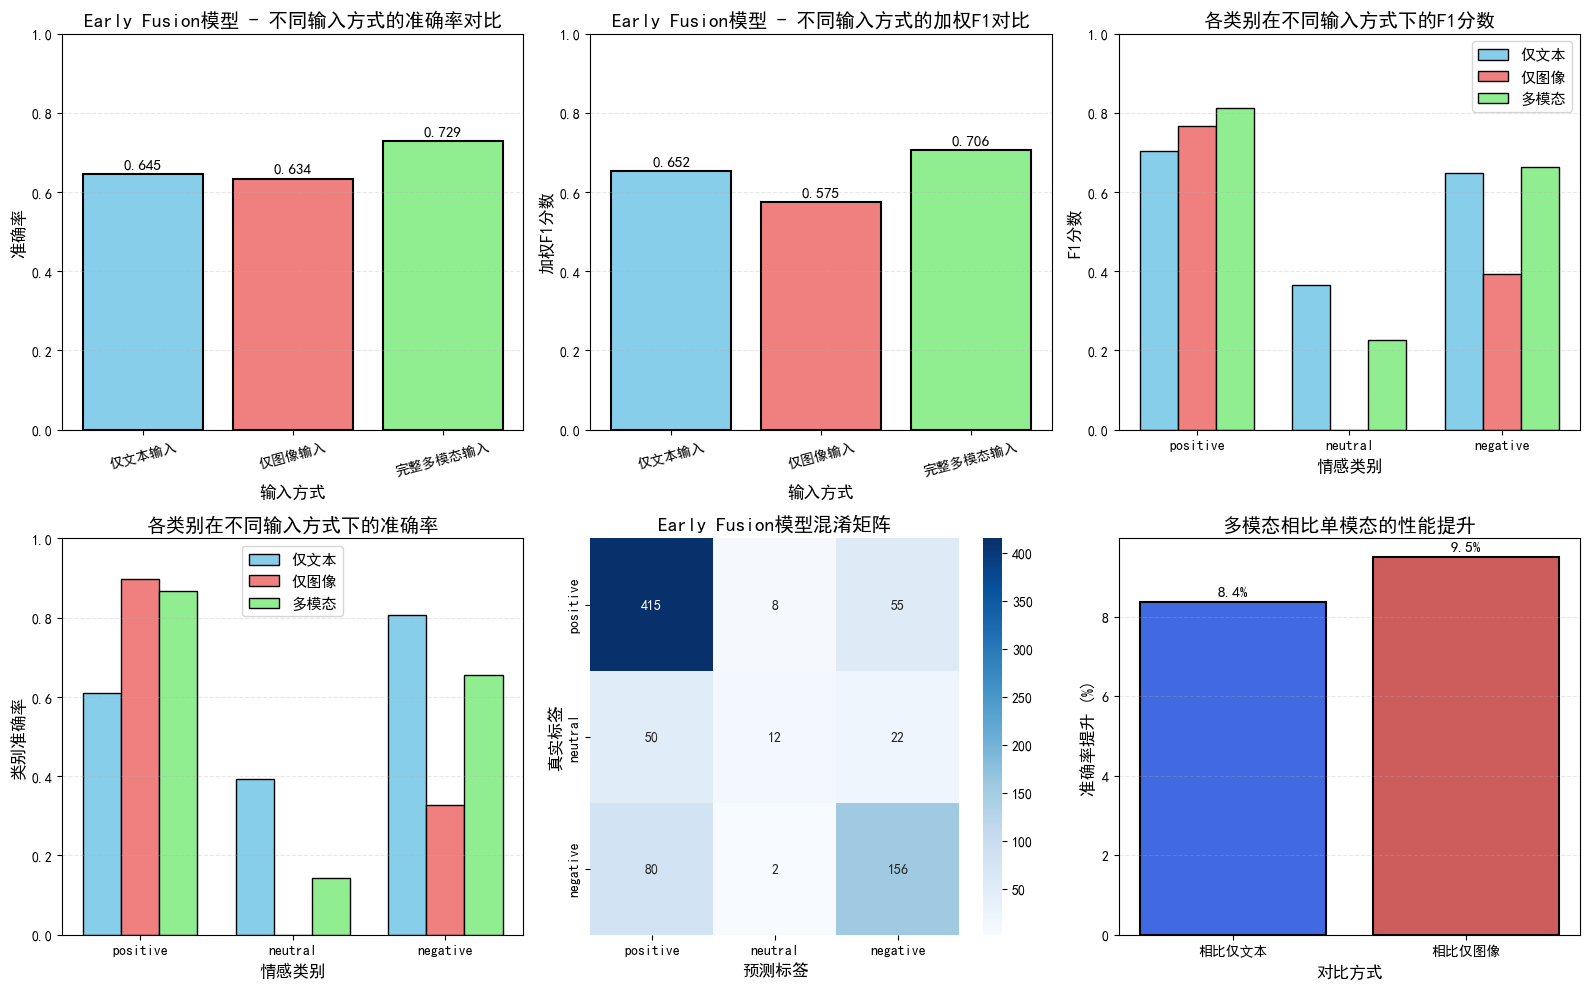


消融实验总结

实验设置:
- 验证集大小: 800 条数据
- 使用模型: Early Fusion最佳超参数模型
- 模型配置: hidden_dim=512, dropout=0.3
- 评估方式: 同一模型在不同输入条件下的表现

实验结果:
1. 仅文本输入准确率: 0.6450 (加权F1: 0.6519)
2. 仅图像输入准确率: 0.6338 (加权F1: 0.5749)
3. 完整多模态输入准确率: 0.7288 (加权F1: 0.7056)

性能提升分析:
多模态相比仅文本提升: 8.38% (绝对), 12.98% (相对)
多模态相比仅图像提升: 9.50% (绝对), 14.99% (相对)

消融实验结果已保存到: early_fusion_ablation_results.txt


In [15]:
print("=" * 80)
print("消融实验 - Early Fusion最佳模型")
print("=" * 80)

# 重新导入必要的模块
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from transformers import BertTokenizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm

# 确保使用相同的配置
config = Config()

# 重新加载数据
print("\n加载数据...")
def load_data_for_ablation():
    train_data = []
    with open(config.train_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines[1:]:
            line = line.strip()
            if line:
                parts = line.split(',')
                if len(parts) >= 2:
                    guid, label = parts[0], parts[1]
                    txt_path = os.path.join(config.data_path, f"{guid}.txt")
                    try:
                        with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                            text = txt_f.read().strip()
                    except:
                        text = ""
                    train_data.append((guid, text, label))
    
    test_data = []
    with open(config.test_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines[1:]:
            line = line.strip()
            if line:
                parts = line.split(',')
                guid = parts[0]
                txt_path = os.path.join(config.data_path, f"{guid}.txt")
                try:
                    with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                        text = txt_f.read().strip()
                except:
                    text = ""
                test_data.append((guid, text, None))
    
    return train_data, test_data

train_data, test_data = load_data_for_ablation()

# 使用与主实验相同的划分方式
from sklearn.model_selection import train_test_split

train_data_full, val_data = train_test_split(
    train_data, 
    test_size=0.2, 
    random_state=42, 
    stratify=[d[2] for d in train_data]
)

print(f"\n进行消融实验:")
print(f"训练数据总数: {len(train_data)}")
print(f"验证集大小: {len(val_data)}")

# 数据预处理
val_transform = transforms.Compose([
    transforms.Resize((config.image_size, config.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 创建验证集
val_dataset = MultimodalDataset(val_data, transform=val_transform)
val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers
)

# 重新定义EarlyFusionModel类（与主实验一致）
class EarlyFusionModelForAblation(nn.Module):
    def __init__(self):
        super(EarlyFusionModelForAblation, self).__init__()
        
        self.text_encoder = BertModel.from_pretrained(config.text_model)
        for param in self.text_encoder.parameters():
            param.requires_grad = False
        for param in self.text_encoder.encoder.layer[-2:].parameters():
            param.requires_grad = True
        
        self.image_encoder = models.resnet50(pretrained=True)
        self.image_encoder = nn.Sequential(*list(self.image_encoder.children())[:-2])
        self.image_pool = nn.AdaptiveAvgPool2d((1, 1))
        for param in self.image_encoder.parameters():
            param.requires_grad = False
        for param in list(self.image_encoder.children())[-4:]:
            for p in param.parameters():
                p.requires_grad = True
        
        self.text_fc = nn.Linear(config.text_dim, config.hidden_dim)
        self.image_fc = nn.Linear(config.image_dim, config.hidden_dim)
        
        # Early Fusion: 文本特征 + 图像特征 + 元素级相乘
        self.fusion = nn.Sequential(
            nn.Linear(config.hidden_dim * 3, config.hidden_dim),
            nn.ReLU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim, config.num_classes)
        )
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, input_ids, attention_mask, image):
        # 文本特征
        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_features = text_out.last_hidden_state[:, 0, :]
        text_features = self.relu(self.text_fc(text_features))
        text_features = self.dropout(text_features)
        
        # 图像特征
        image_features = self.image_encoder(image)
        image_features = self.image_pool(image_features)
        image_features = image_features.view(image_features.size(0), -1)
        image_features = self.relu(self.image_fc(image_features))
        image_features = self.dropout(image_features)
        
        # Early Fusion: 特征交互
        element_wise = text_features * image_features
        fused = torch.cat([text_features, image_features, element_wise], dim=1)
        output = self.fusion(fused)
        
        return output

# 加载训练好的Early Fusion模型
print("\n加载训练好的Early Fusion模型...")
try:
    model = EarlyFusionModelForAblation()
    model_path = 'best_early_fusion_with_exp2_aug.pth'
    if os.path.exists(model_path):
        print(f"找到模型文件: {model_path}")
        model.load_state_dict(torch.load(model_path, map_location=config.device))
        model = model.to(config.device)
        model.eval()
        print("模型加载成功！")
    else:
        print(f"模型文件不存在: {model_path}")
        print("请先运行主实验进行训练")
        exit()
except Exception as e:
    print(f"模型加载失败: {e}")
    import traceback
    traceback.print_exc()
    exit()

# 1. 测试仅文本输入
print("\n" + "=" * 40)
print("测试：仅文本输入（Early Fusion模型）")
print("=" * 40)

def evaluate_text_only_early():
    """仅使用文本数据进行评估"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="仅文本评估", leave=False):
            input_ids = batch['input_ids'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            labels = batch['label'].to(config.device)
            
            # 获取文本特征
            text_out = model.text_encoder(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            text_features = text_out.last_hidden_state[:, 0, :]
            text_features = model.relu(model.text_fc(text_features))
            text_features = model.dropout(text_features)
            
            # 创建零图像特征
            batch_size = input_ids.size(0)
            zero_image_features = torch.zeros(batch_size, model.image_fc.out_features).to(config.device)
            
            # Early Fusion需要3个特征拼接
            element_wise = text_features * zero_image_features
            fused = torch.cat([text_features, zero_image_features, element_wise], dim=1)
            output = model.fusion(fused)
            
            _, preds = torch.max(output, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = float(accuracy_score(all_labels, all_preds))
    f1 = float(f1_score(all_labels, all_preds, average='weighted'))
    
    # 详细分类报告
    print("\n仅文本输入详细分类报告:")
    print("-" * 50)
    report = classification_report(all_labels, all_preds, 
                                   target_names=['positive', 'neutral', 'negative'])
    print(report)
    
    return accuracy, f1, all_preds, all_labels

text_only_acc, text_only_f1, text_preds, text_labels = evaluate_text_only_early()
print(f"仅文本输入 - 准确率: {text_only_acc:.4f}, 加权F1: {text_only_f1:.4f}")

# 2. 测试仅图像输入
print("\n" + "=" * 40)
print("测试：仅图像输入（Early Fusion模型）")
print("=" * 40)

def evaluate_image_only_early():
    """仅使用图像数据进行评估"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="仅图像评估", leave=False):
            images = batch['image'].to(config.device)
            labels = batch['label'].to(config.device)
            
            # 获取图像特征
            image_features = model.image_encoder(images)
            image_features = model.image_pool(image_features)
            image_features = image_features.view(image_features.size(0), -1)
            image_features = model.relu(model.image_fc(image_features))
            image_features = model.dropout(image_features)
            
            # 创建零文本特征
            batch_size = images.size(0)
            zero_text_features = torch.zeros(batch_size, model.text_fc.out_features).to(config.device)
            
            # Early Fusion需要3个特征拼接
            element_wise = zero_text_features * image_features
            fused = torch.cat([zero_text_features, image_features, element_wise], dim=1)
            output = model.fusion(fused)
            
            _, preds = torch.max(output, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = float(accuracy_score(all_labels, all_preds))
    f1 = float(f1_score(all_labels, all_preds, average='weighted'))
    
    # 详细分类报告
    print("\n仅图像输入详细分类报告:")
    print("-" * 50)
    report = classification_report(all_labels, all_preds, 
                                   target_names=['positive', 'neutral', 'negative'])
    print(report)
    
    return accuracy, f1, all_preds, all_labels

image_only_acc, image_only_f1, image_preds, image_labels = evaluate_image_only_early()
print(f"仅图像输入 - 准确率: {image_only_acc:.4f}, 加权F1: {image_only_f1:.4f}")

# 3. 完整多模态测试（用于对比）
print("\n" + "=" * 40)
print("测试：完整多模态输入（Early Fusion）")
print("=" * 40)

def evaluate_full_multimodal_early():
    """使用完整多模态数据进行评估"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="完整多模态评估", leave=False):
            input_ids = batch['input_ids'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            images = batch['image'].to(config.device)
            labels = batch['label'].to(config.device)
            
            outputs = model(input_ids, attention_mask, images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = float(accuracy_score(all_labels, all_preds))
    f1 = float(f1_score(all_labels, all_preds, average='weighted'))
    
    # 详细分类报告
    print("\n多模态输入详细分类报告:")
    print("-" * 50)
    report = classification_report(all_labels, all_preds, 
                                   target_names=['positive', 'neutral', 'negative'])
    print(report)
    
    return accuracy, f1, all_preds, all_labels

full_acc, full_f1, full_preds, full_labels = evaluate_full_multimodal_early()
print(f"完整多模态输入 - 准确率: {full_acc:.4f}, 加权F1: {full_f1:.4f}")

# 4. 结果汇总和对比
print("\n" + "=" * 80)
print("消融实验结果汇总")
print("=" * 80)

results_data = [
    ['仅文本输入', text_only_acc, text_only_f1],
    ['仅图像输入', image_only_acc, image_only_f1],
    ['完整多模态输入', full_acc, full_f1]
]

results_df = pd.DataFrame(results_data, columns=['输入方式', '准确率', '加权F1'])
print("\nEarly Fusion模型在不同输入方式下的表现:")
print("-" * 80)
print(results_df.to_string(index=False, float_format='%.4f'))

# 5. 绘制性能对比图
plt.figure(figsize=(16, 10))

# 子图1：准确率对比
plt.subplot(2, 3, 1)
models_list = results_df['输入方式']
accuracies = results_df['准确率'].values

colors = ['skyblue', 'lightcoral', 'lightgreen']
bars = plt.bar(models_list, accuracies, color=colors, edgecolor='black', linewidth=1.5)
plt.xlabel('输入方式', fontsize=12)
plt.ylabel('准确率', fontsize=12)
plt.title('Early Fusion模型 - 不同输入方式的准确率对比', fontsize=14, fontweight='bold')
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.xticks(rotation=15)

# 在柱子上显示数值
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 子图2：加权F1对比
plt.subplot(2, 3, 2)
f1_scores = results_df['加权F1'].values
bars = plt.bar(models_list, f1_scores, color=colors, edgecolor='black', linewidth=1.5)
plt.xlabel('输入方式', fontsize=12)
plt.ylabel('加权F1分数', fontsize=12)
plt.title('Early Fusion模型 - 不同输入方式的加权F1对比', fontsize=14, fontweight='bold')
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.xticks(rotation=15)

for bar, f1 in zip(bars, f1_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{f1:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 子图3：各类别F1分数对比
plt.subplot(2, 3, 3)

def get_classification_details(preds, labels):
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average=None)
    return precision.astype(float), recall.astype(float), f1.astype(float)

text_precision, text_recall, text_f1 = get_classification_details(text_preds, text_labels)
image_precision, image_recall, image_f1 = get_classification_details(image_preds, image_labels)
full_precision, full_recall, full_f1_class = get_classification_details(full_preds, full_labels)

x = np.arange(3)  # 3个类别
width = 0.25

bars1 = plt.bar(x - width, text_f1, width, label='仅文本', color='skyblue', edgecolor='black')
bars2 = plt.bar(x, image_f1, width, label='仅图像', color='lightcoral', edgecolor='black')
bars3 = plt.bar(x + width, full_f1_class, width, label='多模态', color='lightgreen', edgecolor='black')

plt.xlabel('情感类别', fontsize=12)
plt.ylabel('F1分数', fontsize=12)
plt.title('各类别在不同输入方式下的F1分数', fontsize=14, fontweight='bold')
plt.xticks(x, ['positive', 'neutral', 'negative'])
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.ylim(0, 1.0)

# 子图4：各类别准确率对比
plt.subplot(2, 3, 4)
categories = ['positive', 'neutral', 'negative']

def get_class_accuracy(preds, labels):
    cm = confusion_matrix(labels, preds)
    class_acc = cm.diagonal() / cm.sum(axis=1)
    return class_acc.astype(float)

text_class_acc = get_class_accuracy(text_preds, text_labels)
image_class_acc = get_class_accuracy(image_preds, image_labels)
full_class_acc = get_class_accuracy(full_preds, full_labels)

bars1 = plt.bar(x - width, text_class_acc, width, label='仅文本', color='skyblue', edgecolor='black')
bars2 = plt.bar(x, image_class_acc, width, label='仅图像', color='lightcoral', edgecolor='black')
bars3 = plt.bar(x + width, full_class_acc, width, label='多模态', color='lightgreen', edgecolor='black')

plt.xlabel('情感类别', fontsize=12)
plt.ylabel('类别准确率', fontsize=12)
plt.title('各类别在不同输入方式下的准确率', fontsize=14, fontweight='bold')
plt.xticks(x, categories)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.ylim(0, 1.0)

# 子图5：混淆矩阵热力图
plt.subplot(2, 3, 5)
cm = confusion_matrix(full_labels, full_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['positive', 'neutral', 'negative'],
            yticklabels=['positive', 'neutral', 'negative'])
plt.xlabel('预测标签', fontsize=12)
plt.ylabel('真实标签', fontsize=12)
plt.title('Early Fusion模型混淆矩阵', fontsize=14, fontweight='bold')

# 子图6：性能提升百分比
plt.subplot(2, 3, 6)
text_improvement = (full_acc - text_only_acc) * 100
image_improvement = (full_acc - image_only_acc) * 100

improvements = [text_improvement, image_improvement]
labels_imp = ['相比仅文本', '相比仅图像']
colors_imp = ['royalblue', 'indianred']

bars = plt.bar(labels_imp, improvements, color=colors_imp, edgecolor='black', linewidth=1.5)
plt.xlabel('对比方式', fontsize=12)
plt.ylabel('准确率提升 (%)', fontsize=12)
plt.title('多模态相比单模态的性能提升', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y', linestyle='--')

for bar, imp in zip(bars, improvements):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{imp:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 6. 实验总结
print("\n" + "="*80)
print("消融实验总结")
print("="*80)

print(f"\n实验设置:")
print(f"- 验证集大小: {len(val_data)} 条数据")
print(f"- 使用模型: Early Fusion最佳超参数模型")
print(f"- 模型配置: hidden_dim={config.hidden_dim}, dropout={config.dropout}")
print(f"- 评估方式: 同一模型在不同输入条件下的表现")

print(f"\n实验结果:")
print(f"1. 仅文本输入准确率: {text_only_acc:.4f} (加权F1: {text_only_f1:.4f})")
print(f"2. 仅图像输入准确率: {image_only_acc:.4f} (加权F1: {image_only_f1:.4f})") 
print(f"3. 完整多模态输入准确率: {full_acc:.4f} (加权F1: {full_f1:.4f})")

# 计算性能提升
text_improvement = (full_acc - text_only_acc) * 100
image_improvement = (full_acc - image_only_acc) * 100

# 计算相对提升
text_rel_improvement = (full_acc / text_only_acc - 1) * 100 if text_only_acc > 0 else 0
image_rel_improvement = (full_acc / image_only_acc - 1) * 100 if image_only_acc > 0 else 0

print(f"\n性能提升分析:")
print(f"多模态相比仅文本提升: {text_improvement:.2f}% (绝对), {text_rel_improvement:.2f}% (相对)")
print(f"多模态相比仅图像提升: {image_improvement:.2f}% (绝对), {image_rel_improvement:.2f}% (相对)")

# 保存消融实验结果
with open('early_fusion_ablation_results.txt', 'w', encoding='utf-8') as f:
    f.write("Early Fusion最佳模型消融实验结果\n")
    f.write("="*60 + "\n")
    f.write(f"验证集大小: {len(val_data)} 条数据\n")
    f.write(f"模型配置: hidden_dim={config.hidden_dim}, dropout={config.dropout}\n\n")
    f.write("消融实验结果:\n")
    f.write("-"*30 + "\n")
    f.write(f"仅文本输入准确率: {text_only_acc:.4f} (加权F1: {text_only_f1:.4f})\n")
    f.write(f"仅图像输入准确率: {image_only_acc:.4f} (加权F1: {image_only_f1:.4f})\n")
    f.write(f"完整多模态输入准确率: {full_acc:.4f} (加权F1: {full_f1:.4f})\n\n")
    f.write("性能提升分析:\n")
    f.write(f"多模态相比仅文本: {text_improvement:.2f}% (绝对), {text_rel_improvement:.2f}% (相对)\n")
    f.write(f"多模态相比仅图像: {image_improvement:.2f}% (绝对), {image_rel_improvement:.2f}% (相对)\n")

print(f"\n消融实验结果已保存到: early_fusion_ablation_results.txt")
print("=" * 80)